# Exploratory Data Analysis for Cleaned Financial Datasets

This notebook performs an exploratory analysis of the cleaned financial datasets stored in the processed data folder. The workflow focuses on understanding the available data, reviewing data quality, summarizing distributions, examining relationships, detecting outliers, and deriving business-oriented insights.

The analysis is limited to the data that is present in the cleaned datasets and intentionally avoids forecasting, machine learning, segmentation, and dashboarding.


In [1]:
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

try:
    from IPython import get_ipython
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 180

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger('eda_notebook')

def ensure_directory(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, PROJECT_ROOT.parent, PROJECT_ROOT / 'notebooks']:
    if (candidate / 'data' / 'processed').exists():
        PROJECT_ROOT = candidate
        break
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
ensure_directory(OUTPUT_DIR)


logger.info('Project root: %s', PROJECT_ROOT)

logger.info('Processed data directory: %s', DATA_DIR)

print('Libraries imported and project configuration applied.')

logger.info('Output directory: %s', OUTPUT_DIR)

2026-07-08 16:42:22,036 - INFO - Project root: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics
2026-07-08 16:42:22,036 - INFO - Processed data directory: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/data/processed
2026-07-08 16:42:22,036 - INFO - Output directory: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs


Libraries imported and project configuration applied.


## Project Overview

This notebook provides a structured EDA workflow for the cleaned financial datasets and saves every produced visualization under the outputs directory.


In [2]:
CUSTOMER_FILE = DATA_DIR / 'financial_customers_clean.csv'
TRANSACTION_FILE = DATA_DIR / 'financial_transactions_clean.csv'
REVENUE_FILE = DATA_DIR / 'monthly_revenue_clean.csv'

for path in [CUSTOMER_FILE, TRANSACTION_FILE, REVENUE_FILE]:
    if not path.exists():
        raise FileNotFoundError(f'Required processed dataset not found: {path}')

print('Processed data files resolved successfully.')


Processed data files resolved successfully.


## Load Cleaned Data

The cleaned customer, transaction, and monthly revenue datasets are loaded directly from the processed data folder.


In [3]:
def load_dataset(path: Path) -> pd.DataFrame:
    try:
        df = pd.read_csv(path)
        logger.info('Loaded %s with shape %s', path.name, df.shape)
        return df
    except Exception as exc:
        logger.exception('Failed to load %s', path.name)
        raise RuntimeError(f'Unable to load {path.name}: {exc}') from exc

customers = load_dataset(CUSTOMER_FILE)
transactions = load_dataset(TRANSACTION_FILE)
monthly_revenue = load_dataset(REVENUE_FILE)

print('Datasets loaded successfully.')


2026-07-08 16:42:22,105 - INFO - Loaded financial_customers_clean.csv with shape (20000, 36)
2026-07-08 16:42:22,765 - INFO - Loaded financial_transactions_clean.csv with shape (329202, 30)
2026-07-08 16:42:22,768 - INFO - Loaded monthly_revenue_clean.csv with shape (36, 18)


Datasets loaded successfully.


## Dataset Overview

This section provides a high-level view of each dataset, including row counts, column counts, and basic structure.


In [4]:
def print_dataset_overview(df: pd.DataFrame, name: str) -> None:
    print(f'\n=== {name} ===')
    print(f'Rows: {df.shape[0]:,}')
    print(f'Columns: {df.shape[1]}')
    print('Sample rows:')
    print(df.head(3).to_string(index=False))

print_dataset_overview(customers, 'Customers')
print_dataset_overview(transactions, 'Transactions')
print_dataset_overview(monthly_revenue, 'Monthly Revenue')



=== Customers ===
Rows: 20,000
Columns: 36
Sample rows:
customer_id signup_date  customer_age country region             city   industry company_size subscription_plan contract_type  contract_length_months  monthly_recurring_revenue payment_method  support_tickets  usage_score  login_frequency  nps_score  discount_percentage  tenure_months customer_segment  customer_lifetime_value  customer_acquisition_cost acquisition_channel acquisition_month  is_active  churn last_transaction_date  days_since_last_transaction  frequency_score  monetary_score  average_transaction_value  total_transactions  total_revenue  total_profit customer_profitability  risk_score
CUST_000000  2023-07-31            49 Germany Europe North Judithbury Healthcare   Mid-Market        Enterprise        Annual                      12                    3820.08    Credit Card              6.0         48.7             21.1      -15.0                  8.1             17             Core                 29255.45          

## Data Summary

This section summarises data types, missing values, and the balance between numerical and categorical fields.


In [5]:
def summarize_frame(df: pd.DataFrame, name: str) -> None:
    print(f'\n--- {name} data profile ---')
    print(df.dtypes.astype(str).to_string())
    print('\nMissing values:')
    print(df.isna().sum().to_string())
    numeric_cols = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col])]
    categorical_cols = [col for col in df.columns if col not in numeric_cols]
    print(f'\nNumeric columns: {len(numeric_cols)}')
    print(f'Categorical columns: {len(categorical_cols)}')

summarize_frame(customers, 'Customers')
summarize_frame(transactions, 'Transactions')
summarize_frame(monthly_revenue, 'Monthly Revenue')



--- Customers data profile ---
customer_id                     object
signup_date                     object
customer_age                     int64
country                         object
region                          object
city                            object
industry                        object
company_size                    object
subscription_plan               object
contract_type                   object
contract_length_months           int64
monthly_recurring_revenue      float64
payment_method                  object
support_tickets                float64
usage_score                    float64
login_frequency                float64
nps_score                      float64
discount_percentage            float64
tenure_months                    int64
customer_segment                object
customer_lifetime_value        float64
customer_acquisition_cost      float64
acquisition_channel             object
acquisition_month               object
is_active                       

## Descriptive Statistics

Key descriptive statistics are reviewed for numeric fields to understand central tendency, dispersion, and scale.


In [6]:
numeric_customer_cols = [
    col for col in customers.columns
    if pd.api.types.is_numeric_dtype(customers[col])
    and col not in {'customer_age', 'tenure_months', 'is_active', 'churn'}
]

print('Numeric customer summaries:')
print(customers[numeric_customer_cols].describe().T[['mean', 'std', 'min', '50%', 'max']].round(2).to_string())

print('\nNumeric transaction summaries:')
transaction_numeric = [col for col in transactions.columns if pd.api.types.is_numeric_dtype(transactions[col])]
print(transactions[transaction_numeric].describe().T[['mean', 'std', 'min', '50%', 'max']].round(2).to_string())

print('\nMonthly revenue summaries:')
revenue_numeric = [col for col in monthly_revenue.columns if pd.api.types.is_numeric_dtype(monthly_revenue[col])]
print(monthly_revenue[revenue_numeric].describe().T[['mean', 'std', 'min', '50%', 'max']].round(2).to_string())


Numeric customer summaries:
                                 mean       std     min      50%         max
contract_length_months           8.90      7.77    1.00    12.00       24.00
monthly_recurring_revenue     1016.12   2218.15   14.31   147.77    14266.17
support_tickets                  3.67      2.08    0.00     3.00       14.00
usage_score                     56.48     16.67    1.00    56.00      100.00
login_frequency                 16.94      6.37    0.00    16.90       31.00
nps_score                       10.83     22.78  -79.00    11.00       98.00
discount_percentage              6.15      5.09    0.00     5.60       24.00
customer_lifetime_value      25785.83  91927.72   21.38   558.43  1160678.75
customer_acquisition_cost     1552.82   3394.69   22.03   344.48    41909.73
days_since_last_transaction     79.57    129.66    0.00    35.00     1016.00
frequency_score                  3.00      1.41    1.00     3.00        5.00
monetary_score                   3.00      1.41 

## Missing Values Review

The missing value profile is reviewed to determine whether the data is complete enough for reliable analysis.


In [7]:
def plot_missing_values(df: pd.DataFrame, name: str) -> None:
    missing_summary = df.isna().sum().sort_values(ascending=False)
    missing_summary = missing_summary[missing_summary > 0]
    if missing_summary.empty:
        print(f'{name}: no missing values detected.')
        return

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=missing_summary.index, y=missing_summary.values, palette='Reds_r', ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(f'Missing Values by Column - {name}')
    ax.set_ylabel('Missing Count')
    fig.tight_layout()
    output_path = OUTPUT_DIR / f'{name.lower().replace(" ", "_")}_missing_values.png'
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {output_path}')
    print('Business insight: missing values are concentrated in a small subset of fields, which reduces the risk of broad data quality issues.')

plot_missing_values(customers, 'Customers')
plot_missing_values(transactions, 'Transactions')
plot_missing_values(monthly_revenue, 'Monthly Revenue')


Customers: no missing values detected.
Transactions: no missing values detected.
Monthly Revenue: no missing values detected.


## Numerical Feature Analysis

The numerical fields are inspected through distributions and spread to identify concentration, skewness, and scale differences.


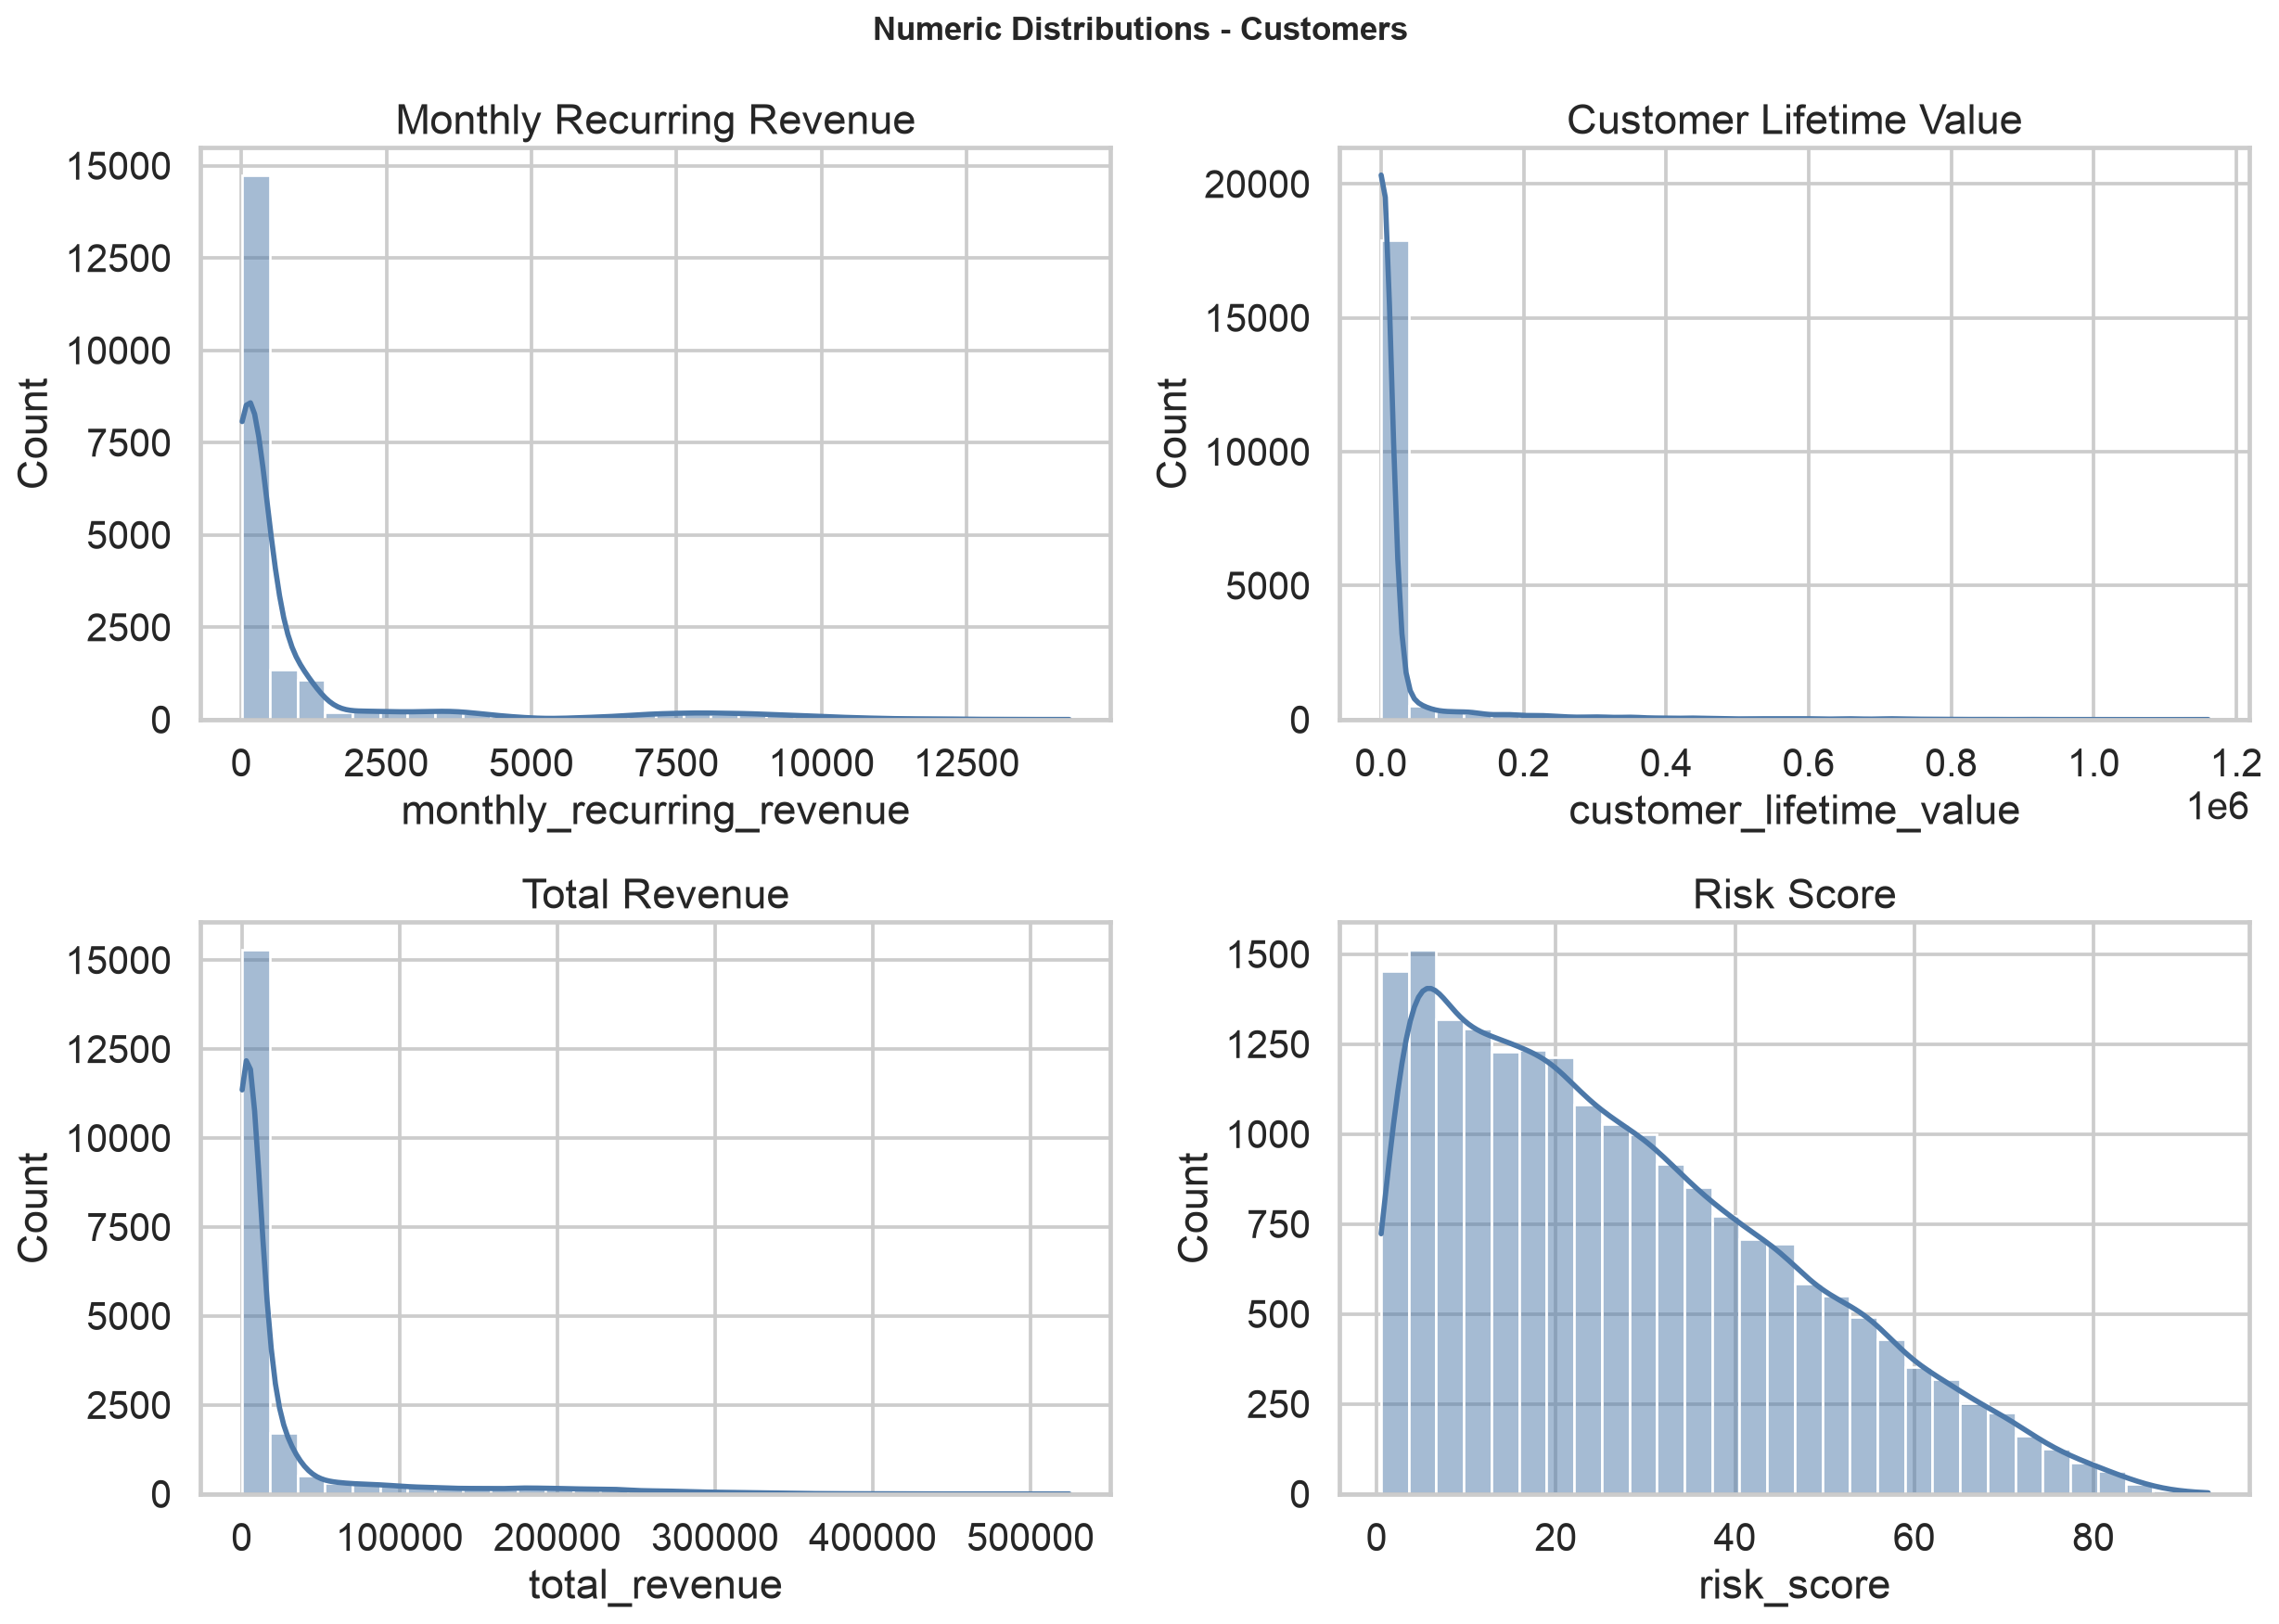

Saved: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/customers_numeric_distributions.png
Business insight: the spread of the numeric fields shows whether revenue and customer value are concentrated or broadly distributed.


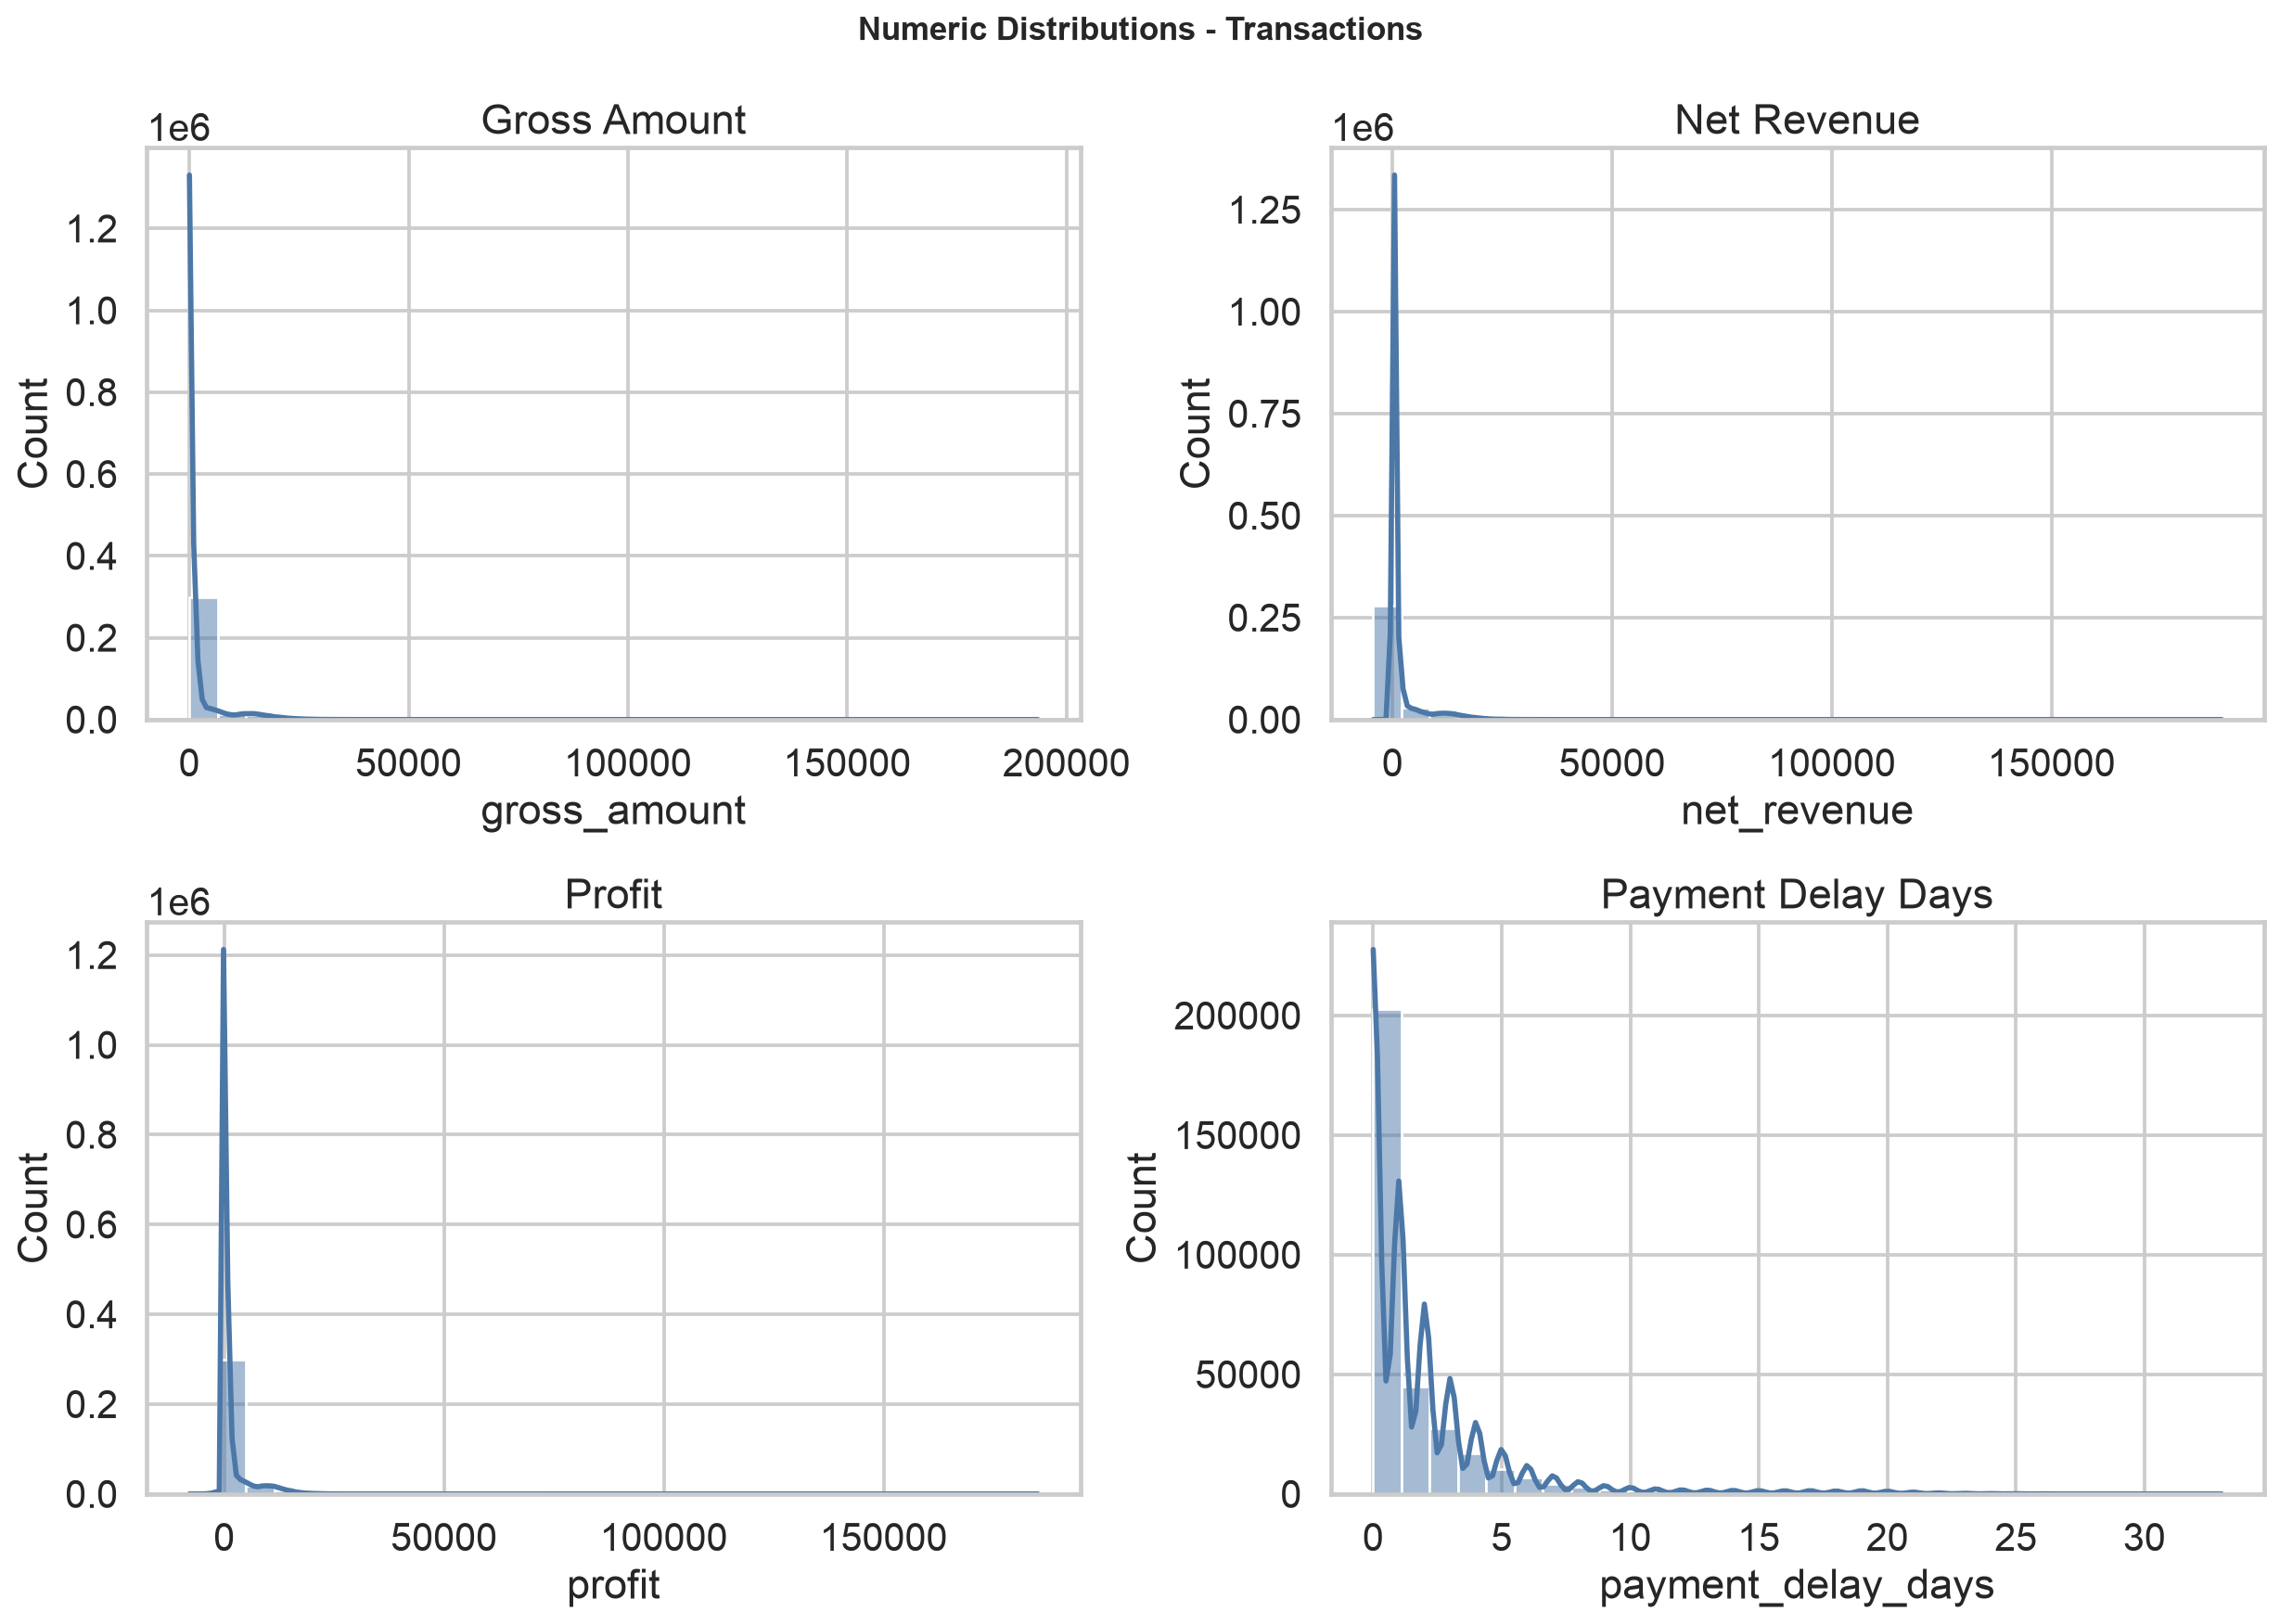

Saved: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/transactions_numeric_distributions.png
Business insight: the spread of the numeric fields shows whether revenue and customer value are concentrated or broadly distributed.


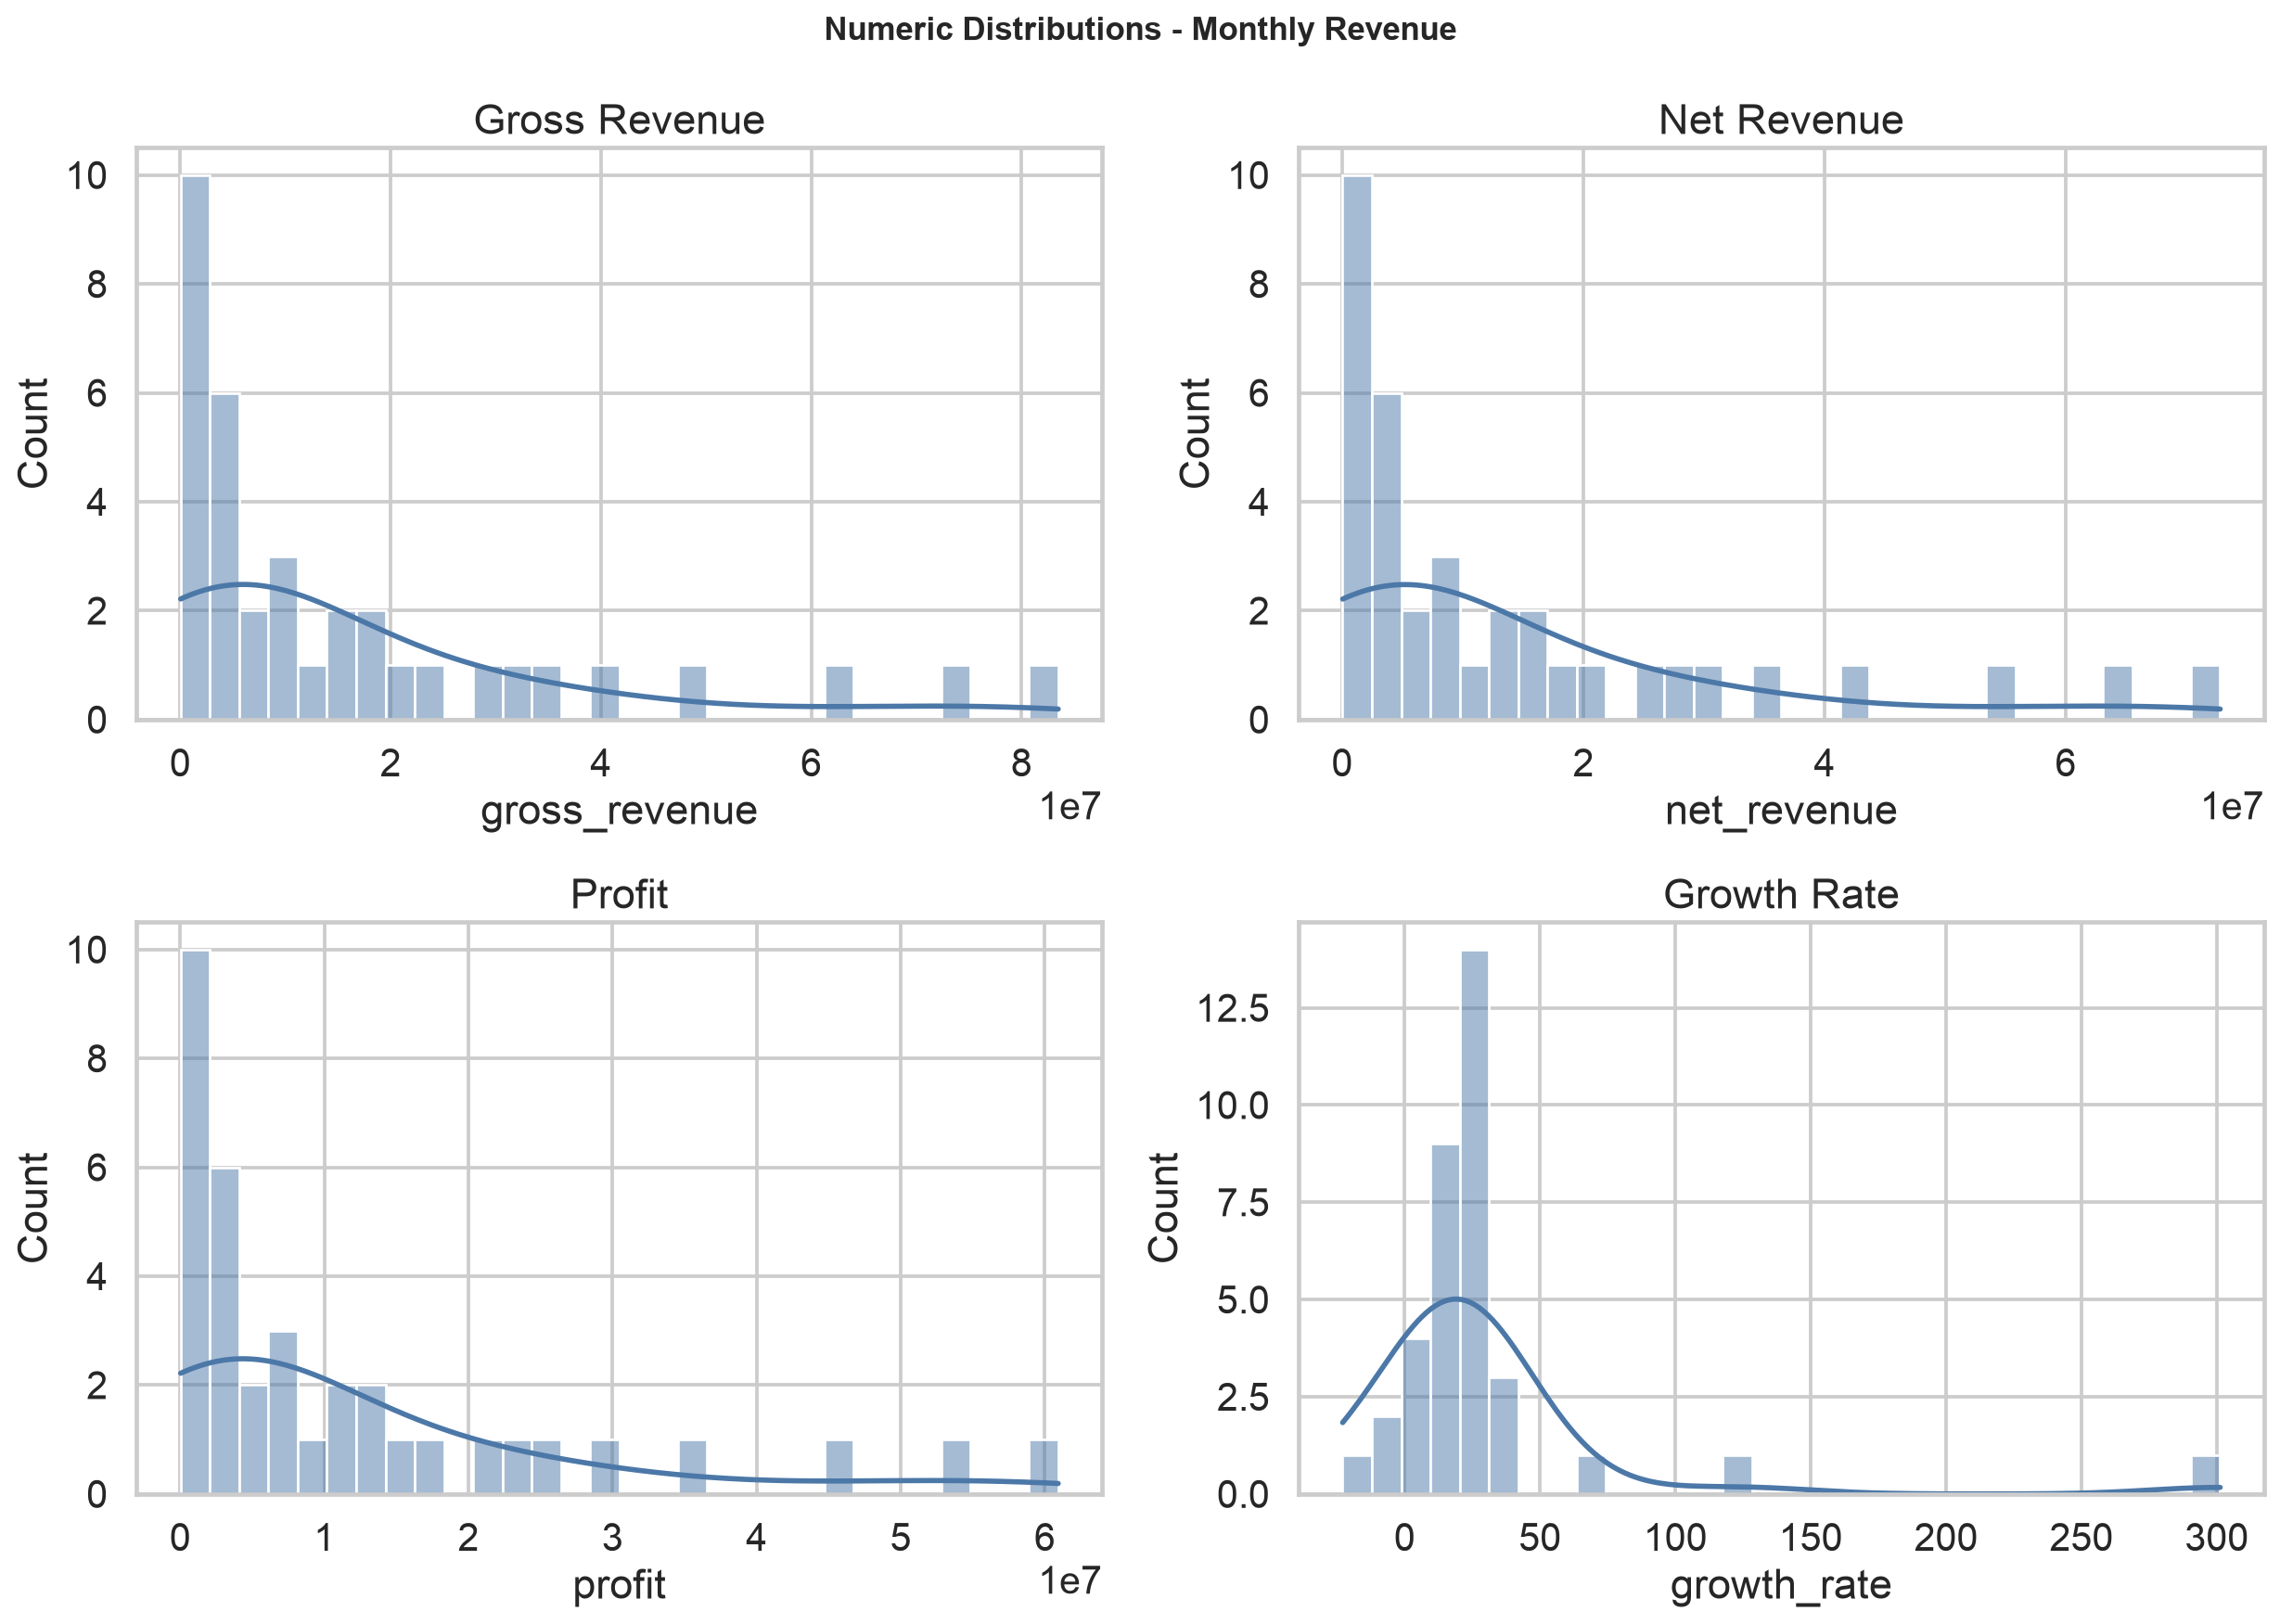

Saved: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/monthly_revenue_numeric_distributions.png
Business insight: the spread of the numeric fields shows whether revenue and customer value are concentrated or broadly distributed.


In [8]:
def plot_numeric_distributions(df: pd.DataFrame, cols, name: str) -> None:
    selected = [col for col in cols if col in df.columns]
    if len(selected) < 2:
        print('Insufficient numeric columns for distribution analysis.')
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    for ax, col in zip(axes, selected[:4]):
        sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax, color='#4C78A8')
        ax.set_title(col.replace('_', ' ').title())
        ax.set_xlabel(col)
    for ax in axes[len(selected[:4]):]:
        ax.axis('off')
    fig.suptitle(f'Numeric Distributions - {name}', fontsize=14, fontweight='bold')
    fig.tight_layout()
    output_path = OUTPUT_DIR / f'{name.lower().replace(" ", "_")}_numeric_distributions.png'
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {output_path}')
    print('Business insight: the spread of the numeric fields shows whether revenue and customer value are concentrated or broadly distributed.')

plot_numeric_distributions(customers, ['monthly_recurring_revenue', 'customer_lifetime_value', 'total_revenue', 'risk_score'], 'Customers')
plot_numeric_distributions(transactions, ['gross_amount', 'net_revenue', 'profit', 'payment_delay_days'], 'Transactions')
plot_numeric_distributions(monthly_revenue, ['gross_revenue', 'net_revenue', 'profit', 'growth_rate'], 'Monthly Revenue')


## Categorical Feature Analysis

The categorical fields are reviewed to understand the composition of customers, payment methods, regions, and other business dimensions.


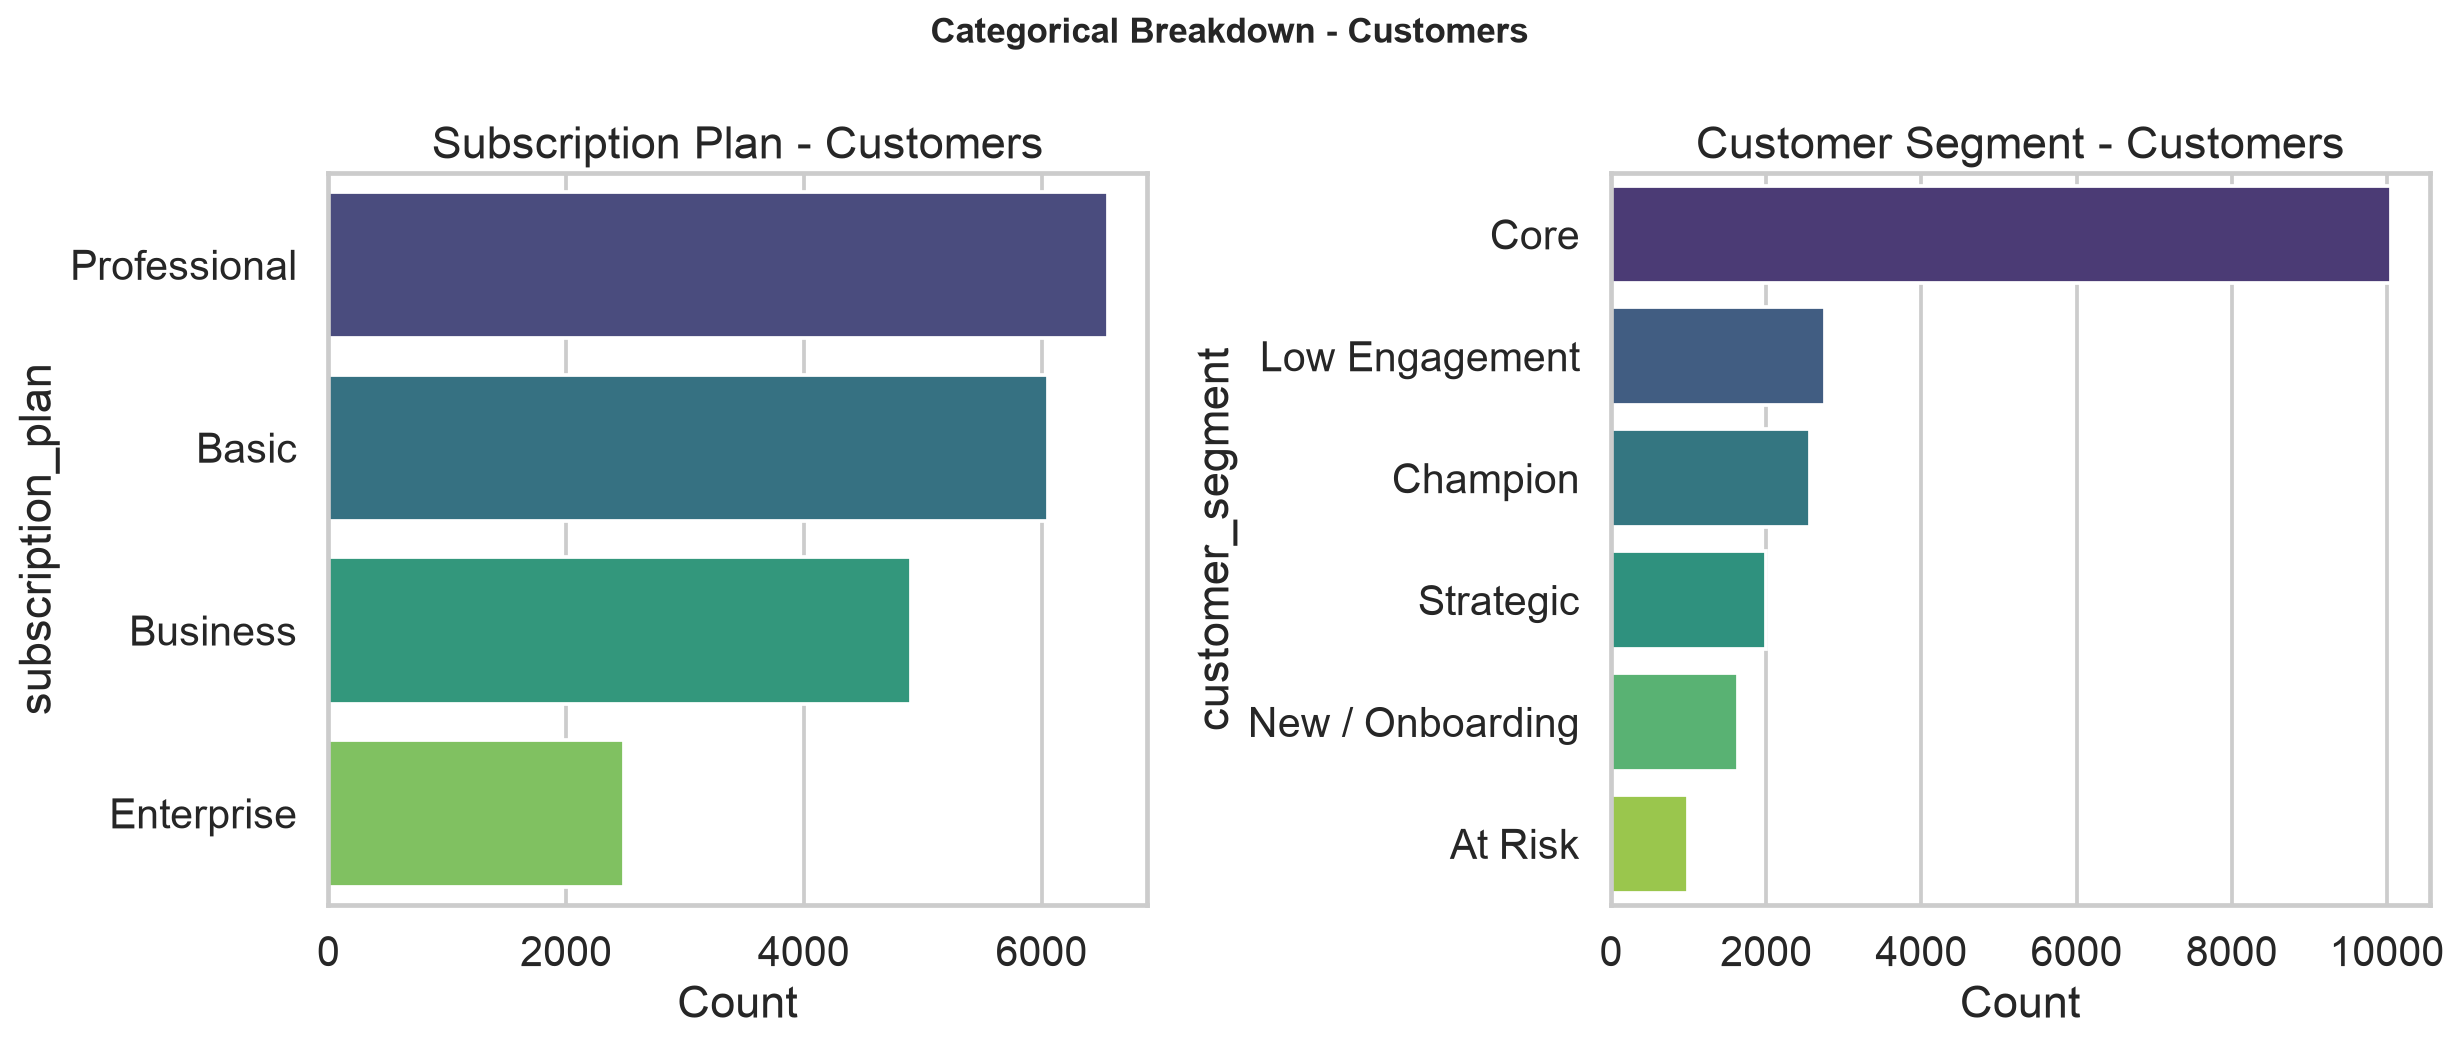

Saved: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/customers_categorical_breakdown.png
Business insight: the categorical profile helps identify the most common customer and transaction segments that shape the business base.


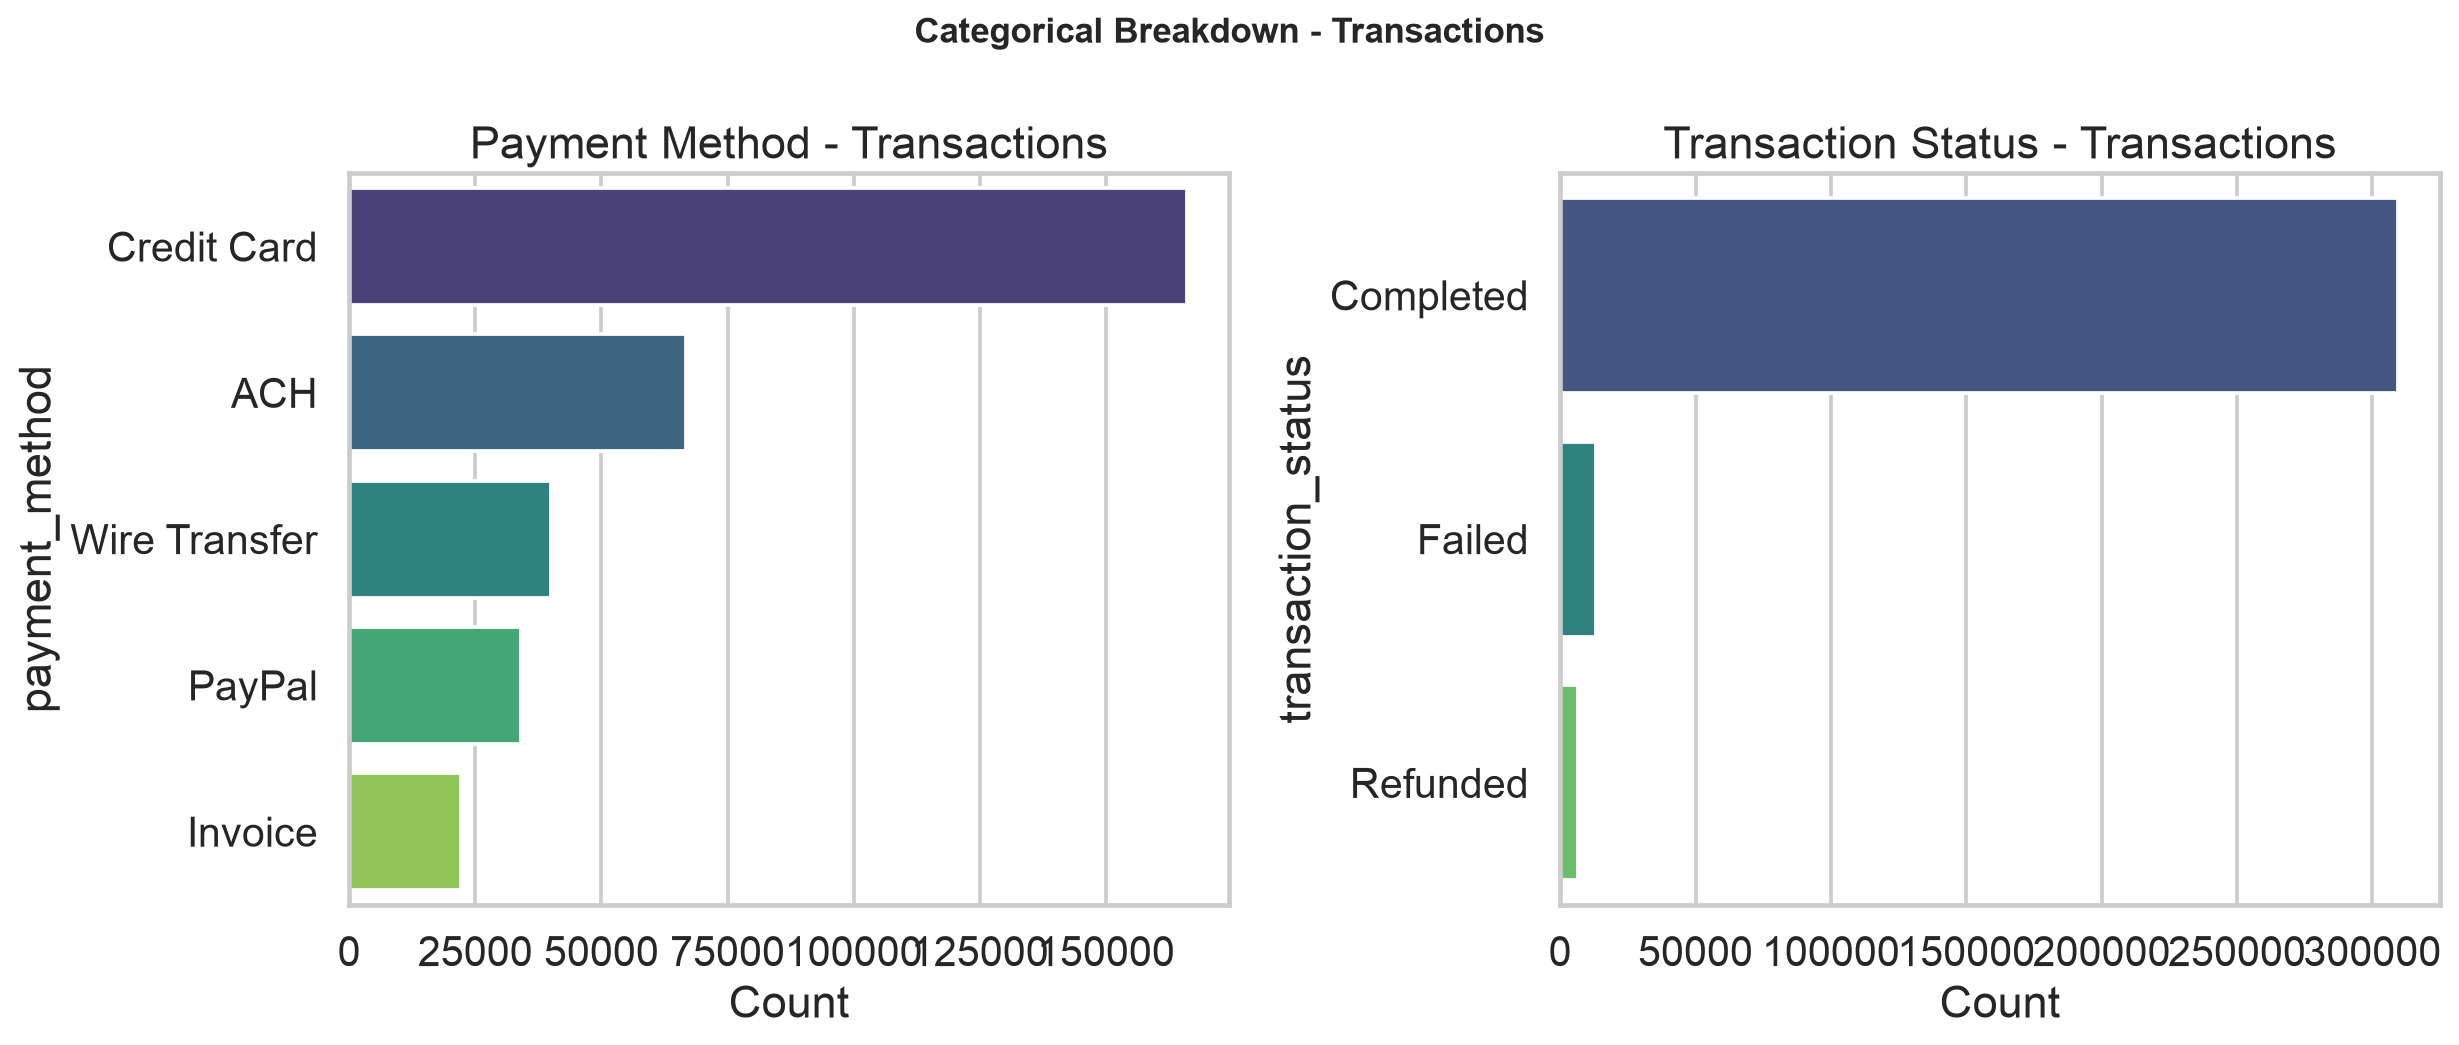

2026-07-08 16:42:27,165 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-08 16:42:27,167 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Saved: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/transactions_categorical_breakdown.png
Business insight: the categorical profile helps identify the most common customer and transaction segments that shape the business base.


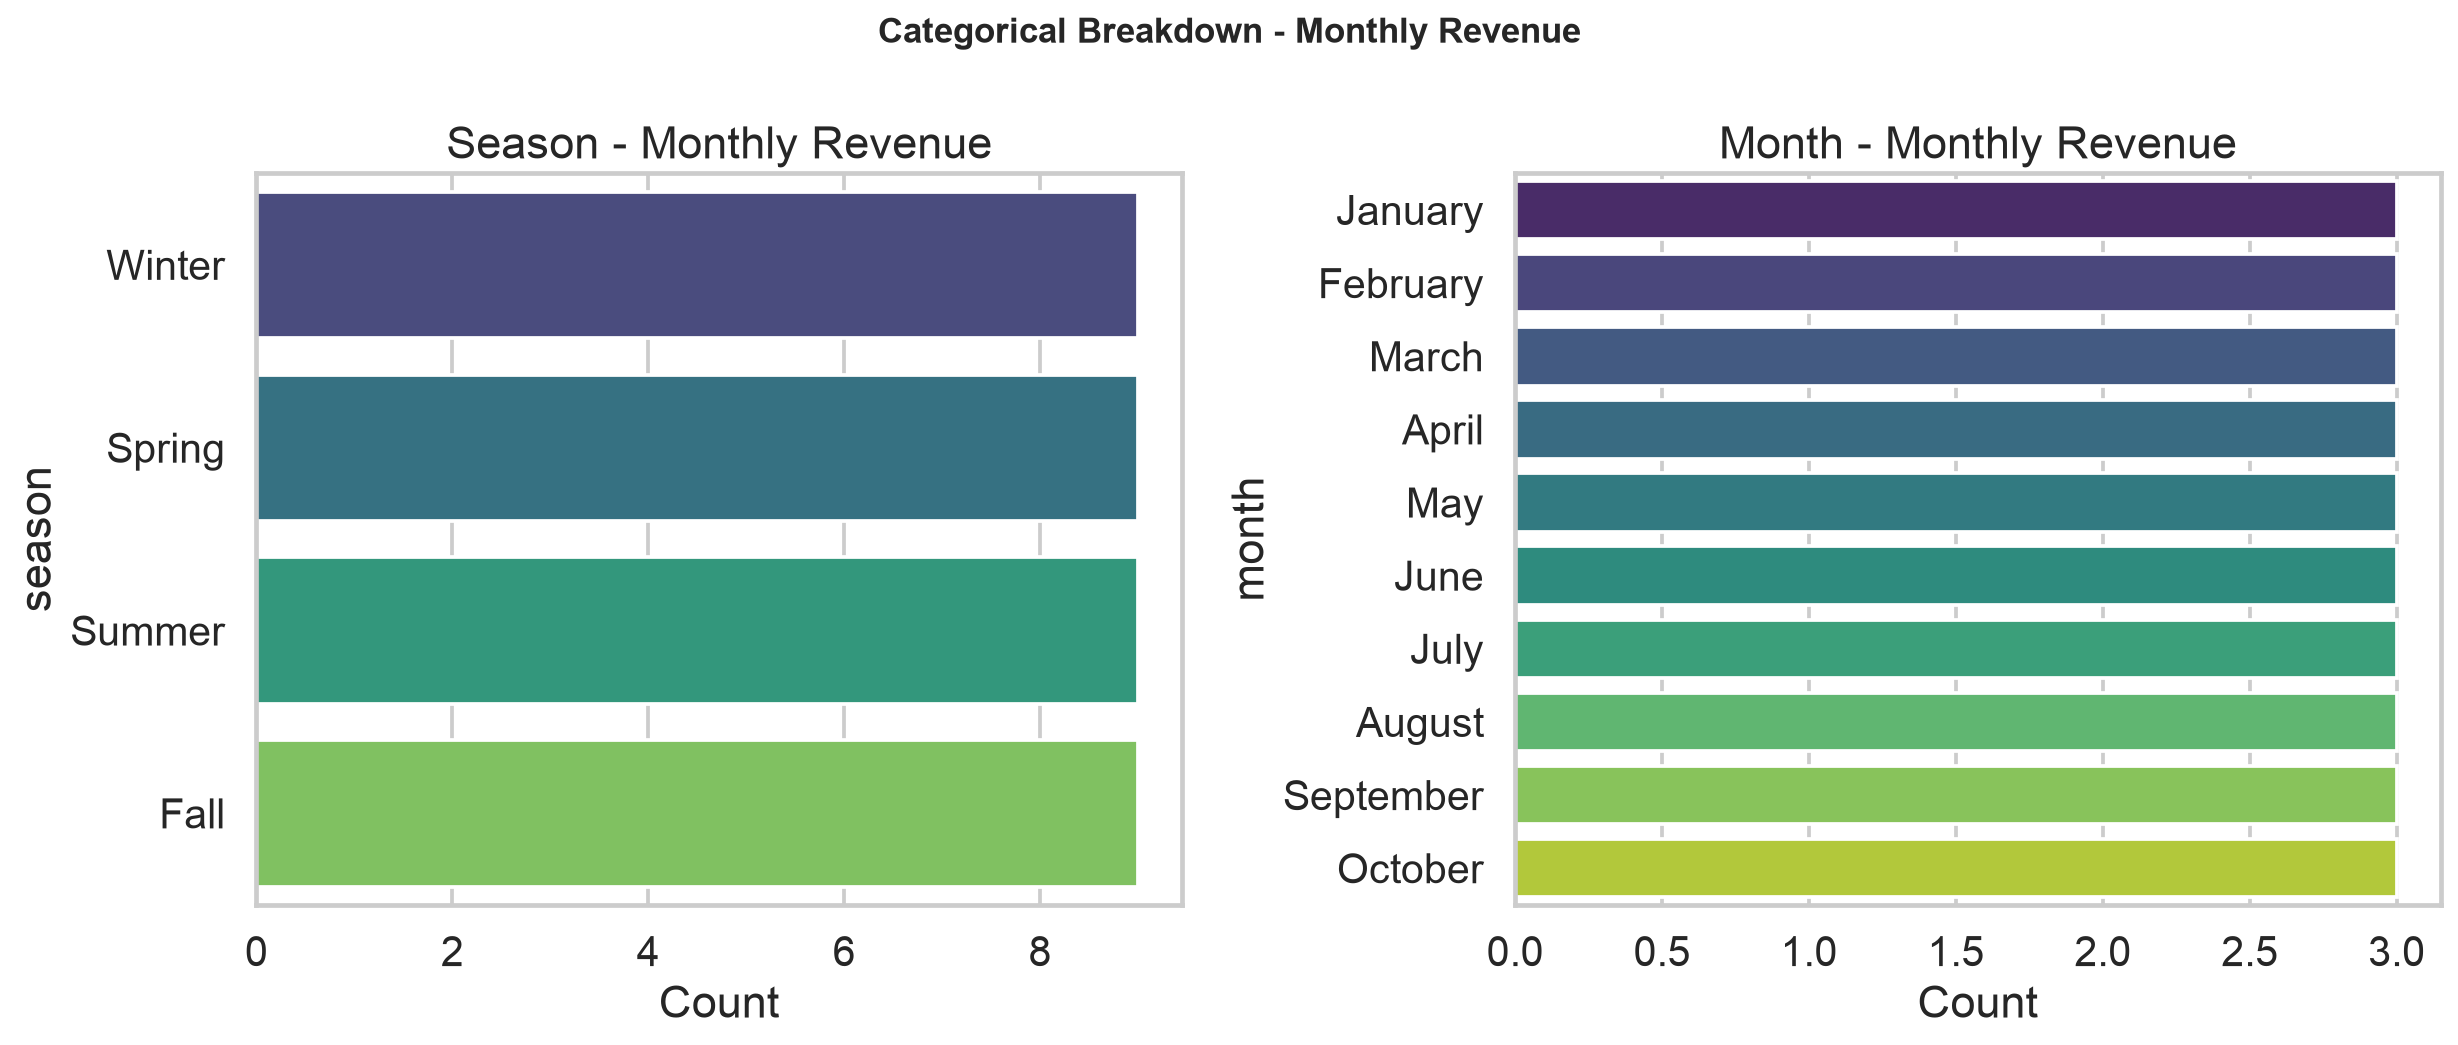

Saved: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/monthly_revenue_categorical_breakdown.png
Business insight: the categorical profile helps identify the most common customer and transaction segments that shape the business base.


In [9]:
def plot_categorical_breakdown(df: pd.DataFrame, cols, name: str) -> None:
    selected = [col for col in cols if col in df.columns]
    if not selected:
        print('No categorical columns available for plotting.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, col in zip(axes, selected[:2]):
        counts = df[col].fillna('Missing').value_counts().head(10)
        sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='viridis')
        ax.set_title(f'{col.replace("_", " ").title()} - {name}')
        ax.set_xlabel('Count')
        ax.set_ylabel(col)
    fig.suptitle(f'Categorical Breakdown - {name}', fontsize=14, fontweight='bold')
    fig.tight_layout()
    output_path = OUTPUT_DIR / f'{name.lower().replace(" ", "_")}_categorical_breakdown.png'
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {output_path}')
    print('Business insight: the categorical profile helps identify the most common customer and transaction segments that shape the business base.')

plot_categorical_breakdown(customers, ['subscription_plan', 'customer_segment'], 'Customers')
plot_categorical_breakdown(transactions, ['payment_method', 'transaction_status'], 'Transactions')
plot_categorical_breakdown(monthly_revenue, ['season', 'month'], 'Monthly Revenue')


## Univariate Analysis

This section focuses on single-variable distributions to understand shape, skewness, and concentration for business-critical measures.


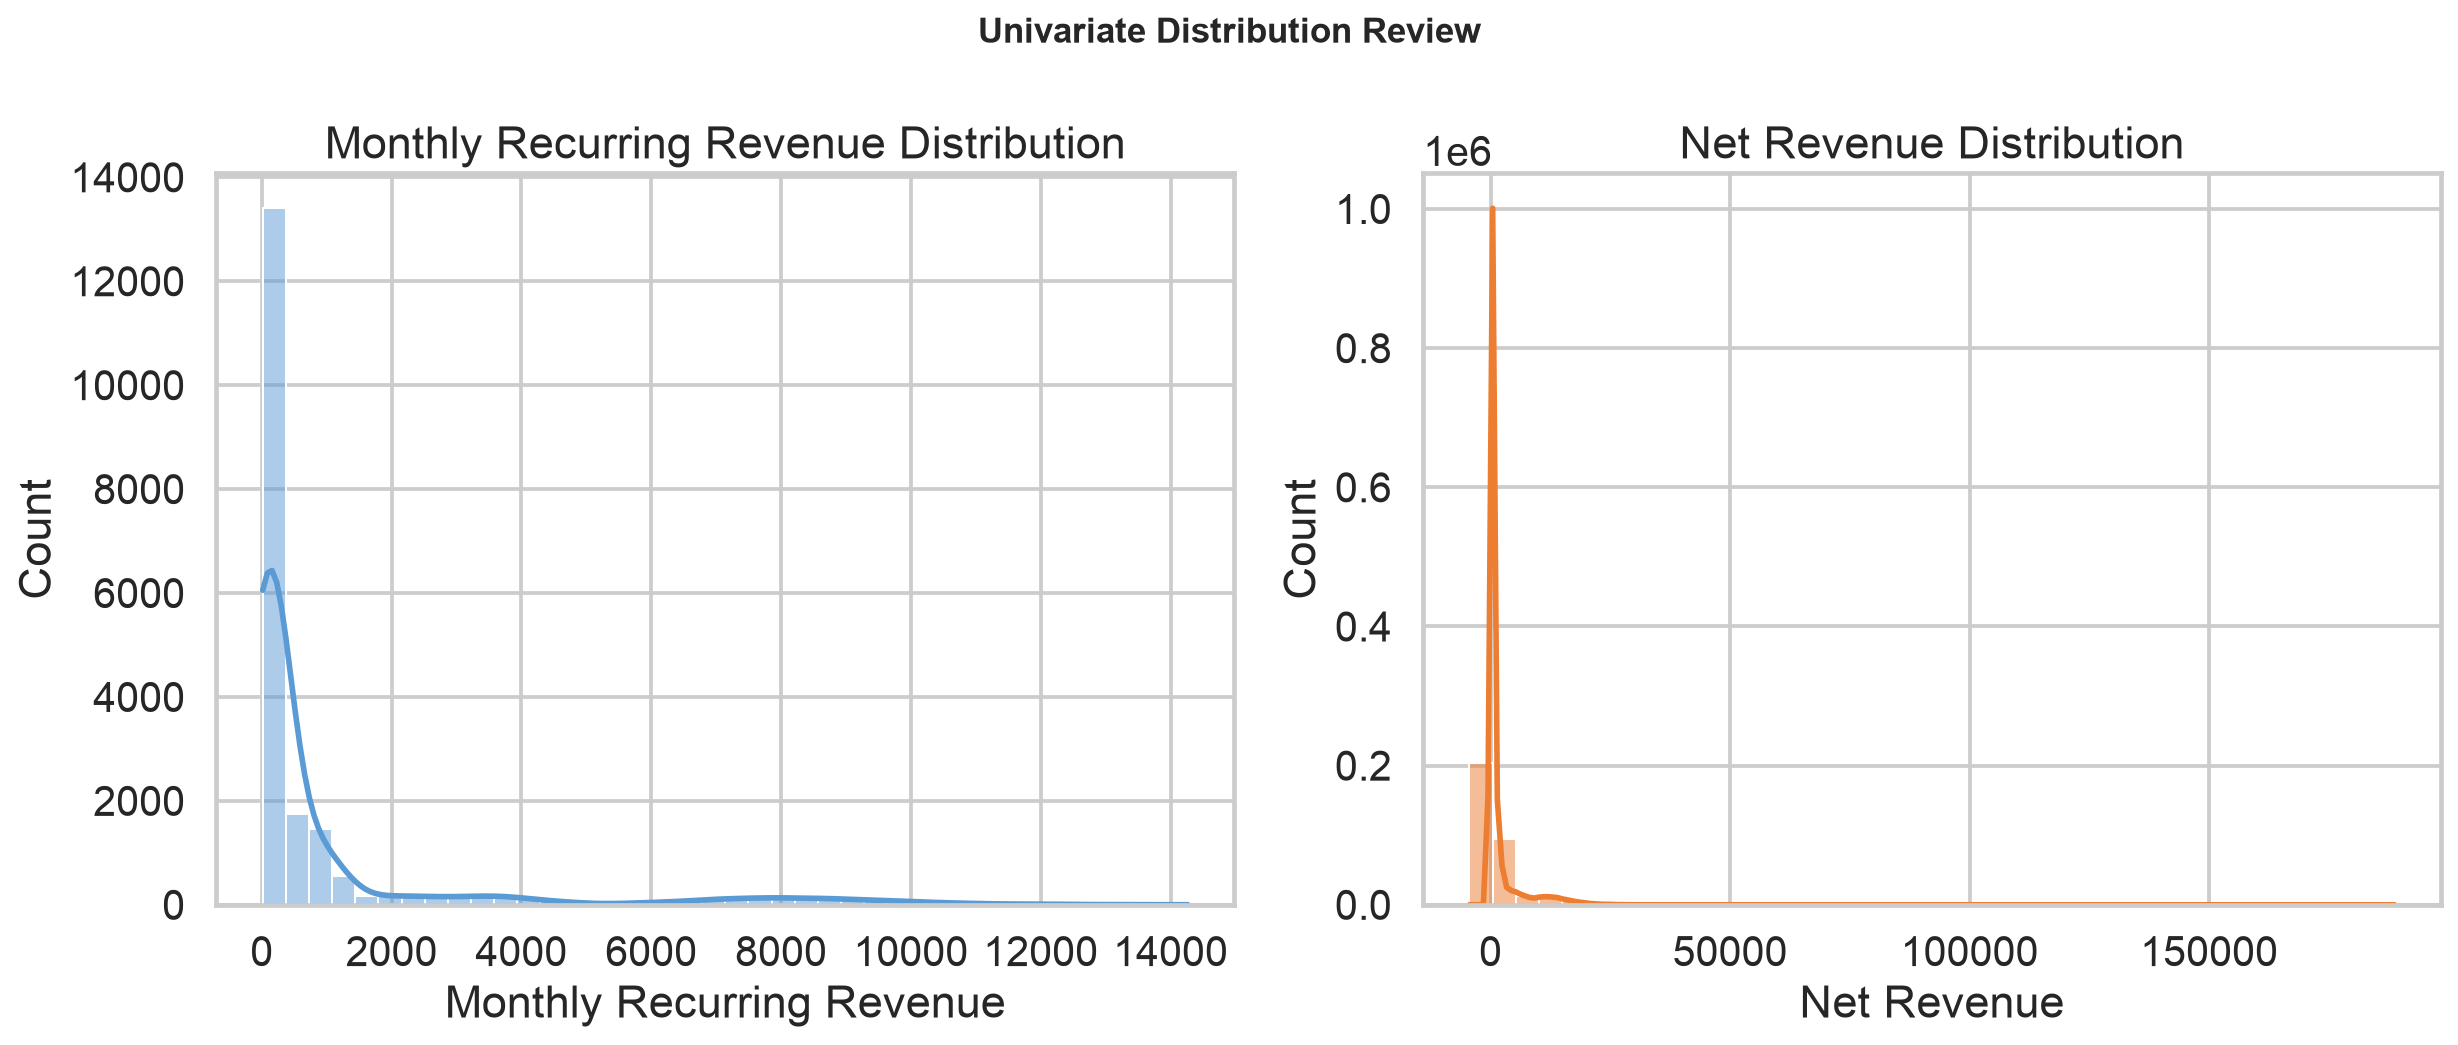

Saved: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/univariate_distribution_review.png
Business insight: the revenue distributions indicate whether the customer base is dominated by a small number of high-value accounts or a broader, more even spread.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(customers['monthly_recurring_revenue'].dropna(), bins=40, kde=True, ax=axes[0], color='#5A9BD5')
axes[0].set_title('Monthly Recurring Revenue Distribution')
axes[0].set_xlabel('Monthly Recurring Revenue')

sns.histplot(transactions['net_revenue'].dropna(), bins=40, kde=True, ax=axes[1], color='#ED7D31')
axes[1].set_title('Net Revenue Distribution')
axes[1].set_xlabel('Net Revenue')
fig.suptitle('Univariate Distribution Review', fontsize=14, fontweight='bold')
fig.tight_layout()
output_path = OUTPUT_DIR / 'univariate_distribution_review.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {output_path}')
print('Business insight: the revenue distributions indicate whether the customer base is dominated by a small number of high-value accounts or a broader, more even spread.')


## Bivariate Analysis

The relationship between selected numeric and categorical variables is reviewed to identify business-relevant patterns.


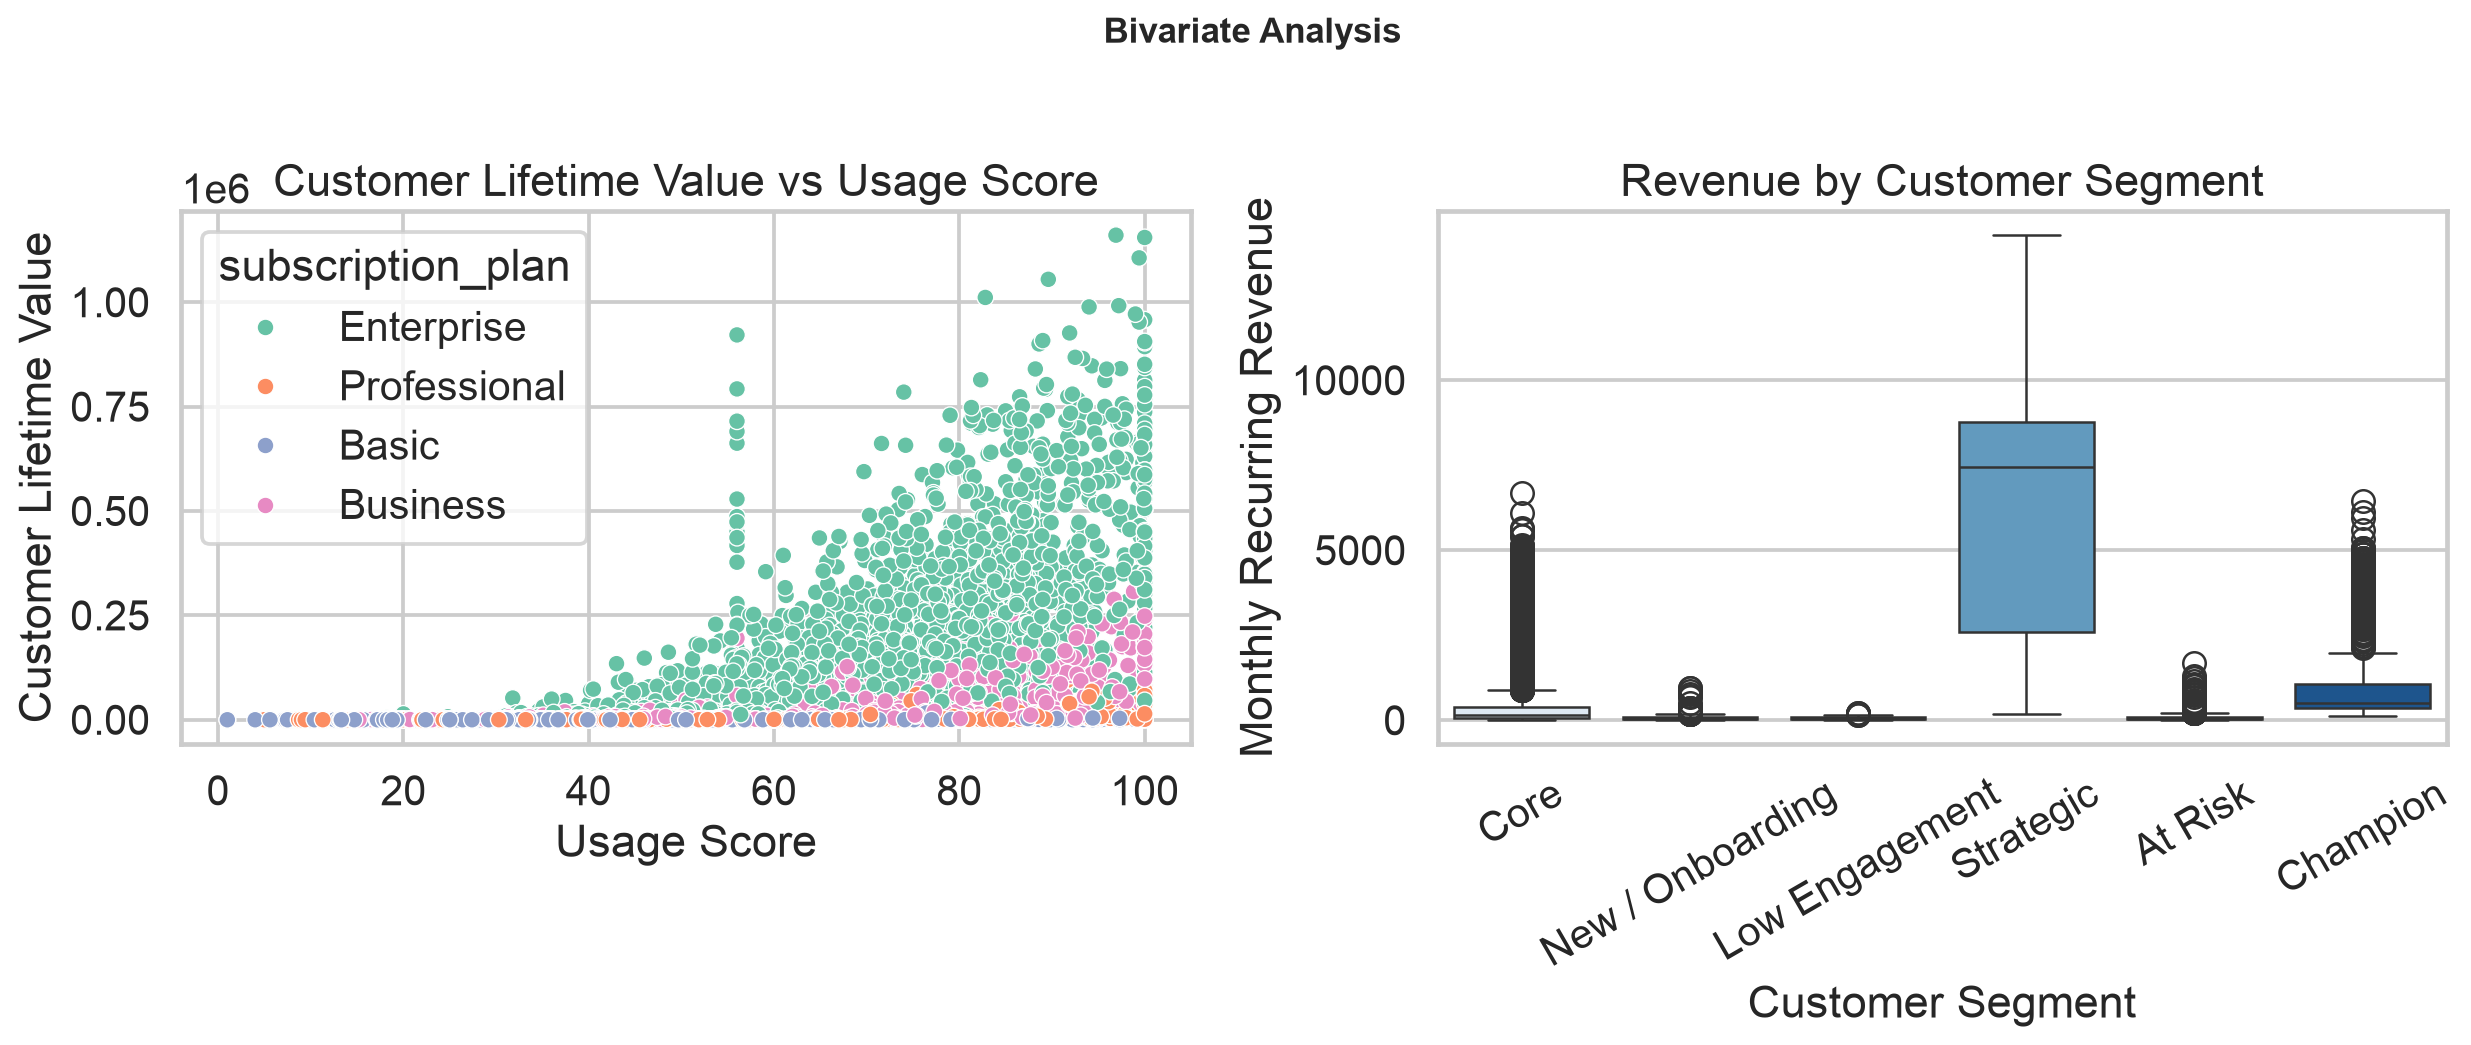

Saved: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/bivariate_analysis.png
Business insight: stronger product usage and higher-value segments appear to align with higher revenue potential, which is useful for prioritizing account-level strategy.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(data=customers, x='usage_score', y='customer_lifetime_value', hue='subscription_plan', s=45, ax=axes[0], palette='Set2')
axes[0].set_title('Customer Lifetime Value vs Usage Score')
axes[0].set_xlabel('Usage Score')
axes[0].set_ylabel('Customer Lifetime Value')

sns.boxplot(data=customers, x='customer_segment', y='monthly_recurring_revenue', palette='Blues', ax=axes[1])
axes[1].set_title('Revenue by Customer Segment')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Monthly Recurring Revenue')
axes[1].tick_params(axis='x', rotation=30)
fig.suptitle('Bivariate Analysis', fontsize=14, fontweight='bold')
fig.tight_layout()
output_path = OUTPUT_DIR / 'bivariate_analysis.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {output_path}')
print('Business insight: stronger product usage and higher-value segments appear to align with higher revenue potential, which is useful for prioritizing account-level strategy.')


## Multivariate Analysis

Multiple variables are examined together to understand how customer value, engagement, and risk appear in combination.


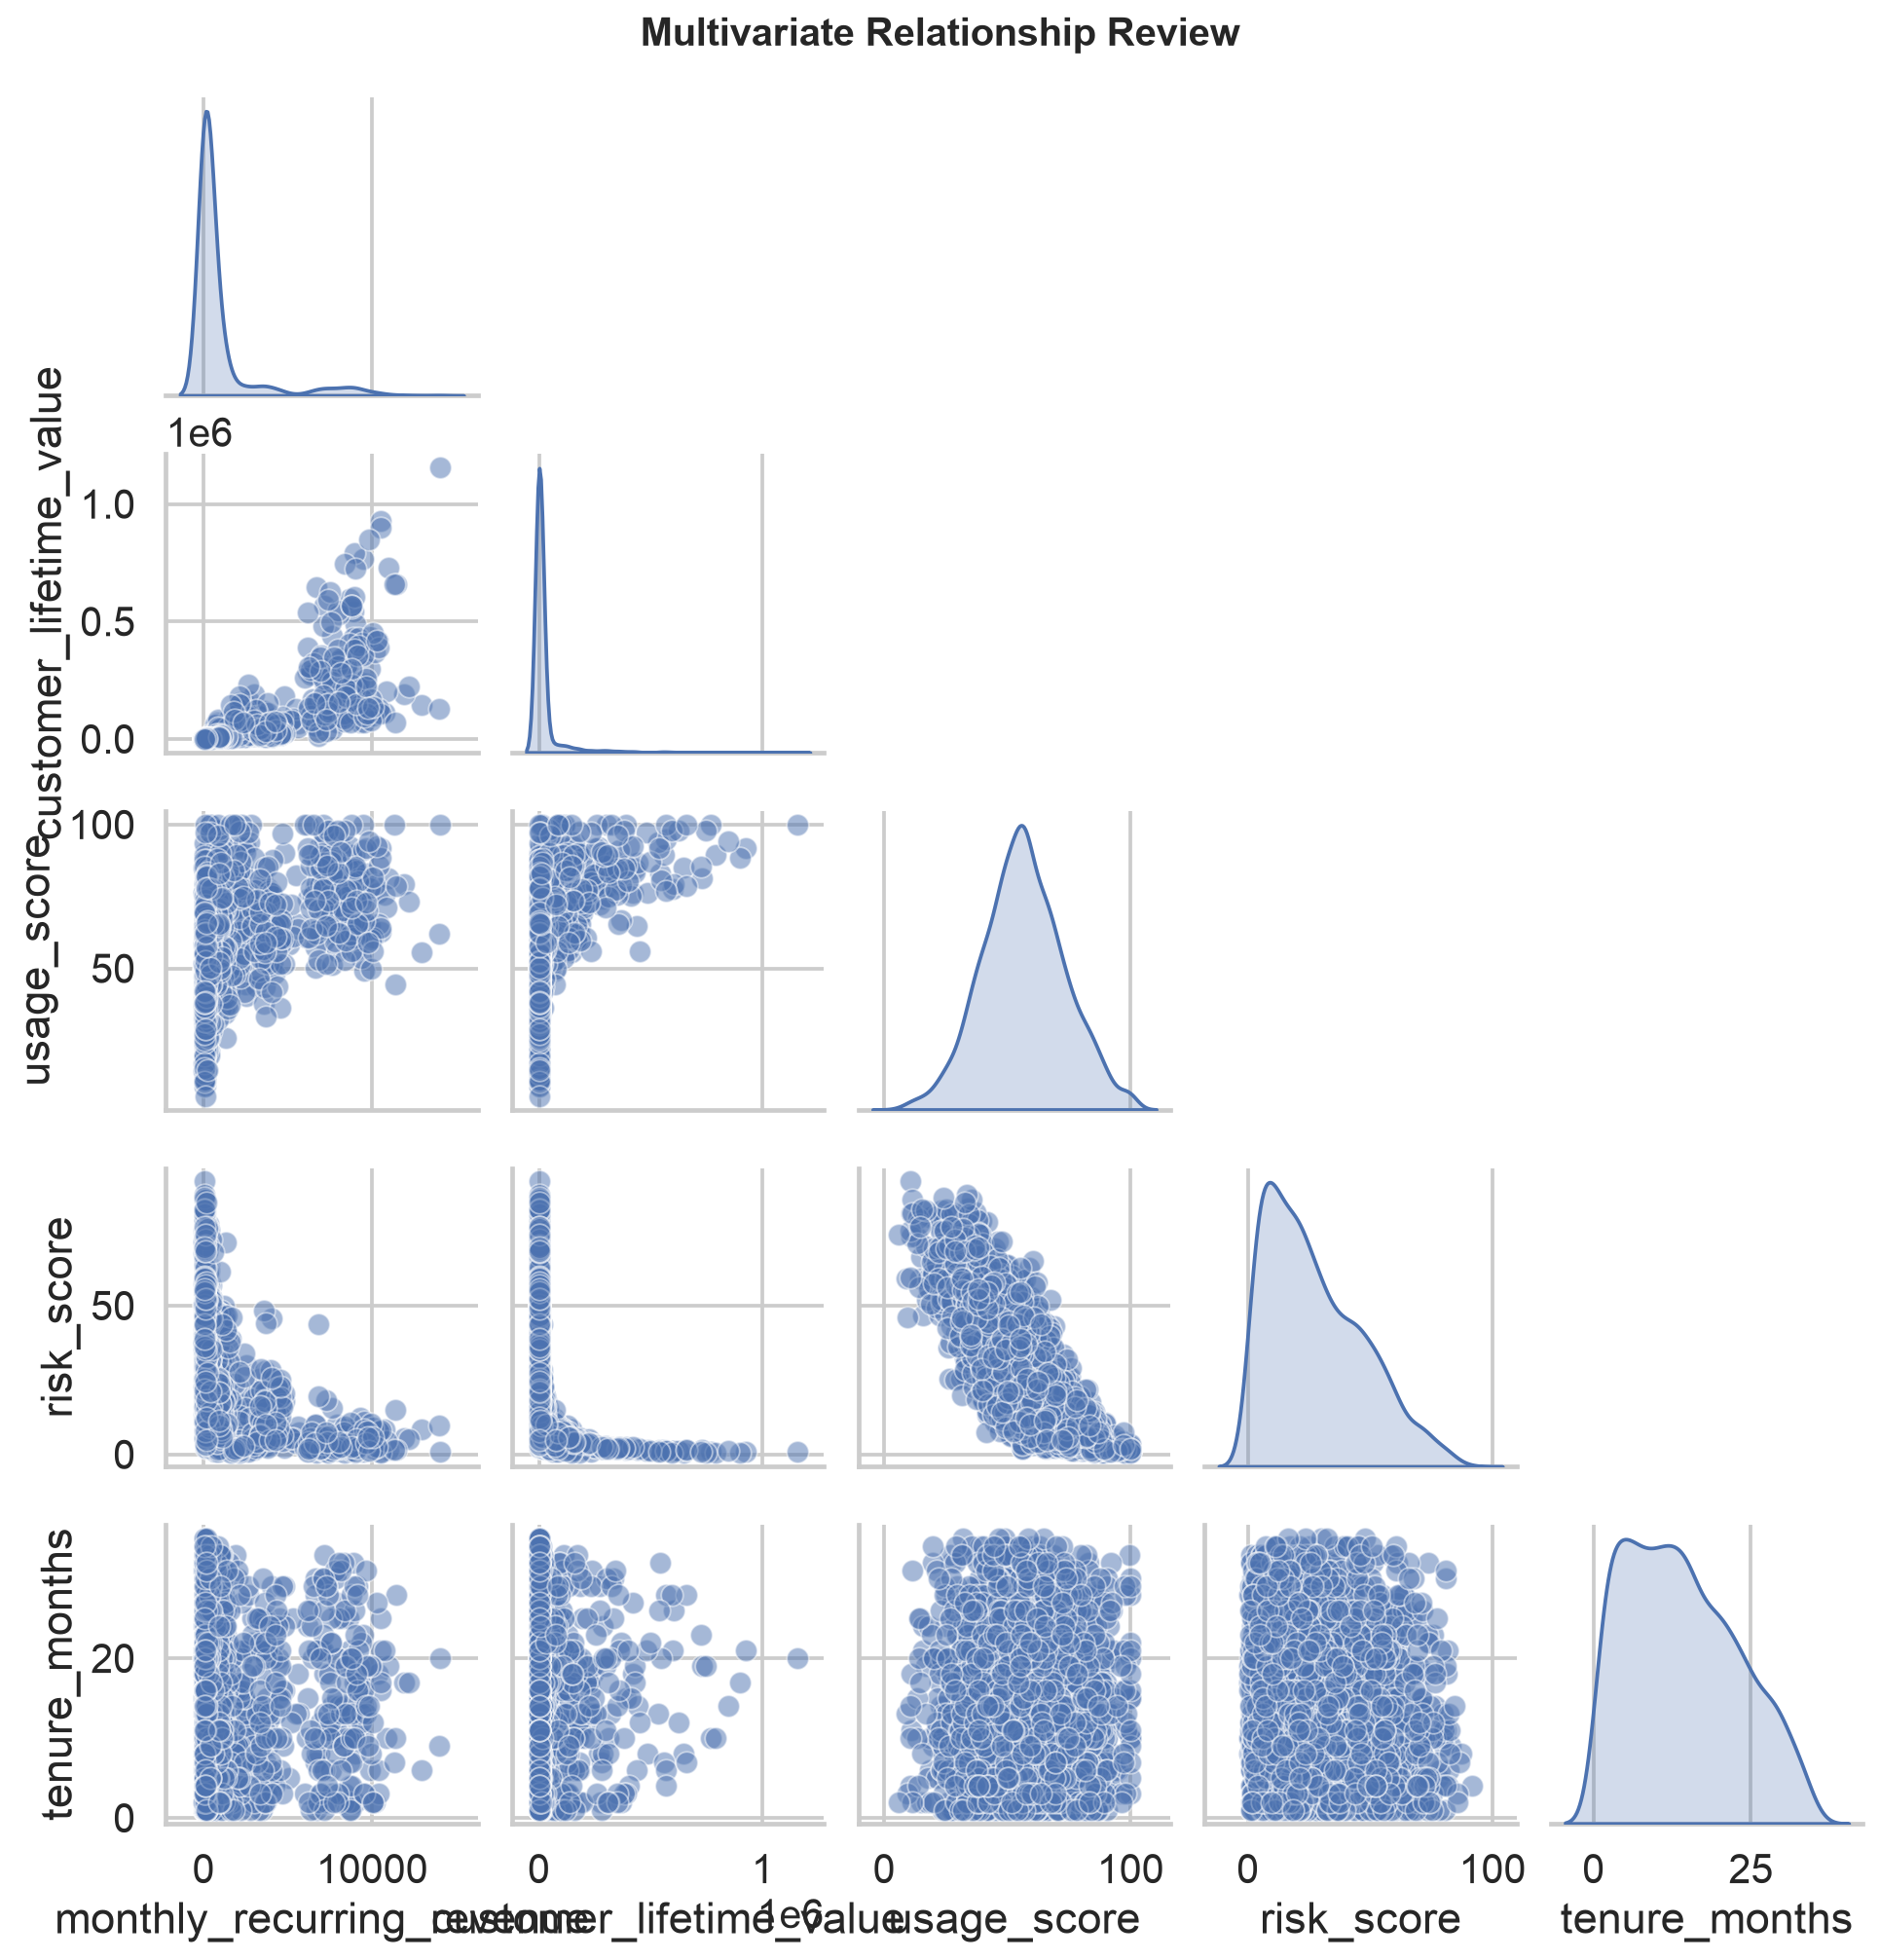

Saved: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/multivariate_relationship_review.png
Business insight: the joint patterns suggest that engagement, tenure, and value measures move together and should be interpreted collectively rather than in isolation.


In [12]:
pair_columns = ['monthly_recurring_revenue', 'customer_lifetime_value', 'usage_score', 'risk_score', 'tenure_months']
pair_frame = customers[pair_columns].dropna().sample(n=min(2500, len(customers)), random_state=42)
pair_plot = sns.pairplot(pair_frame, corner=True, diag_kind='kde', height=2.2, plot_kws={'alpha': 0.5})
pair_plot.fig.suptitle('Multivariate Relationship Review', fontsize=16, fontweight='bold', y=1.02)
output_path = OUTPUT_DIR / 'multivariate_relationship_review.png'
pair_plot.fig.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {output_path}')
print('Business insight: the joint patterns suggest that engagement, tenure, and value measures move together and should be interpreted collectively rather than in isolation.')


## Correlation Analysis

A correlation heatmap highlights the strength and direction of relationships between key numerical measures.


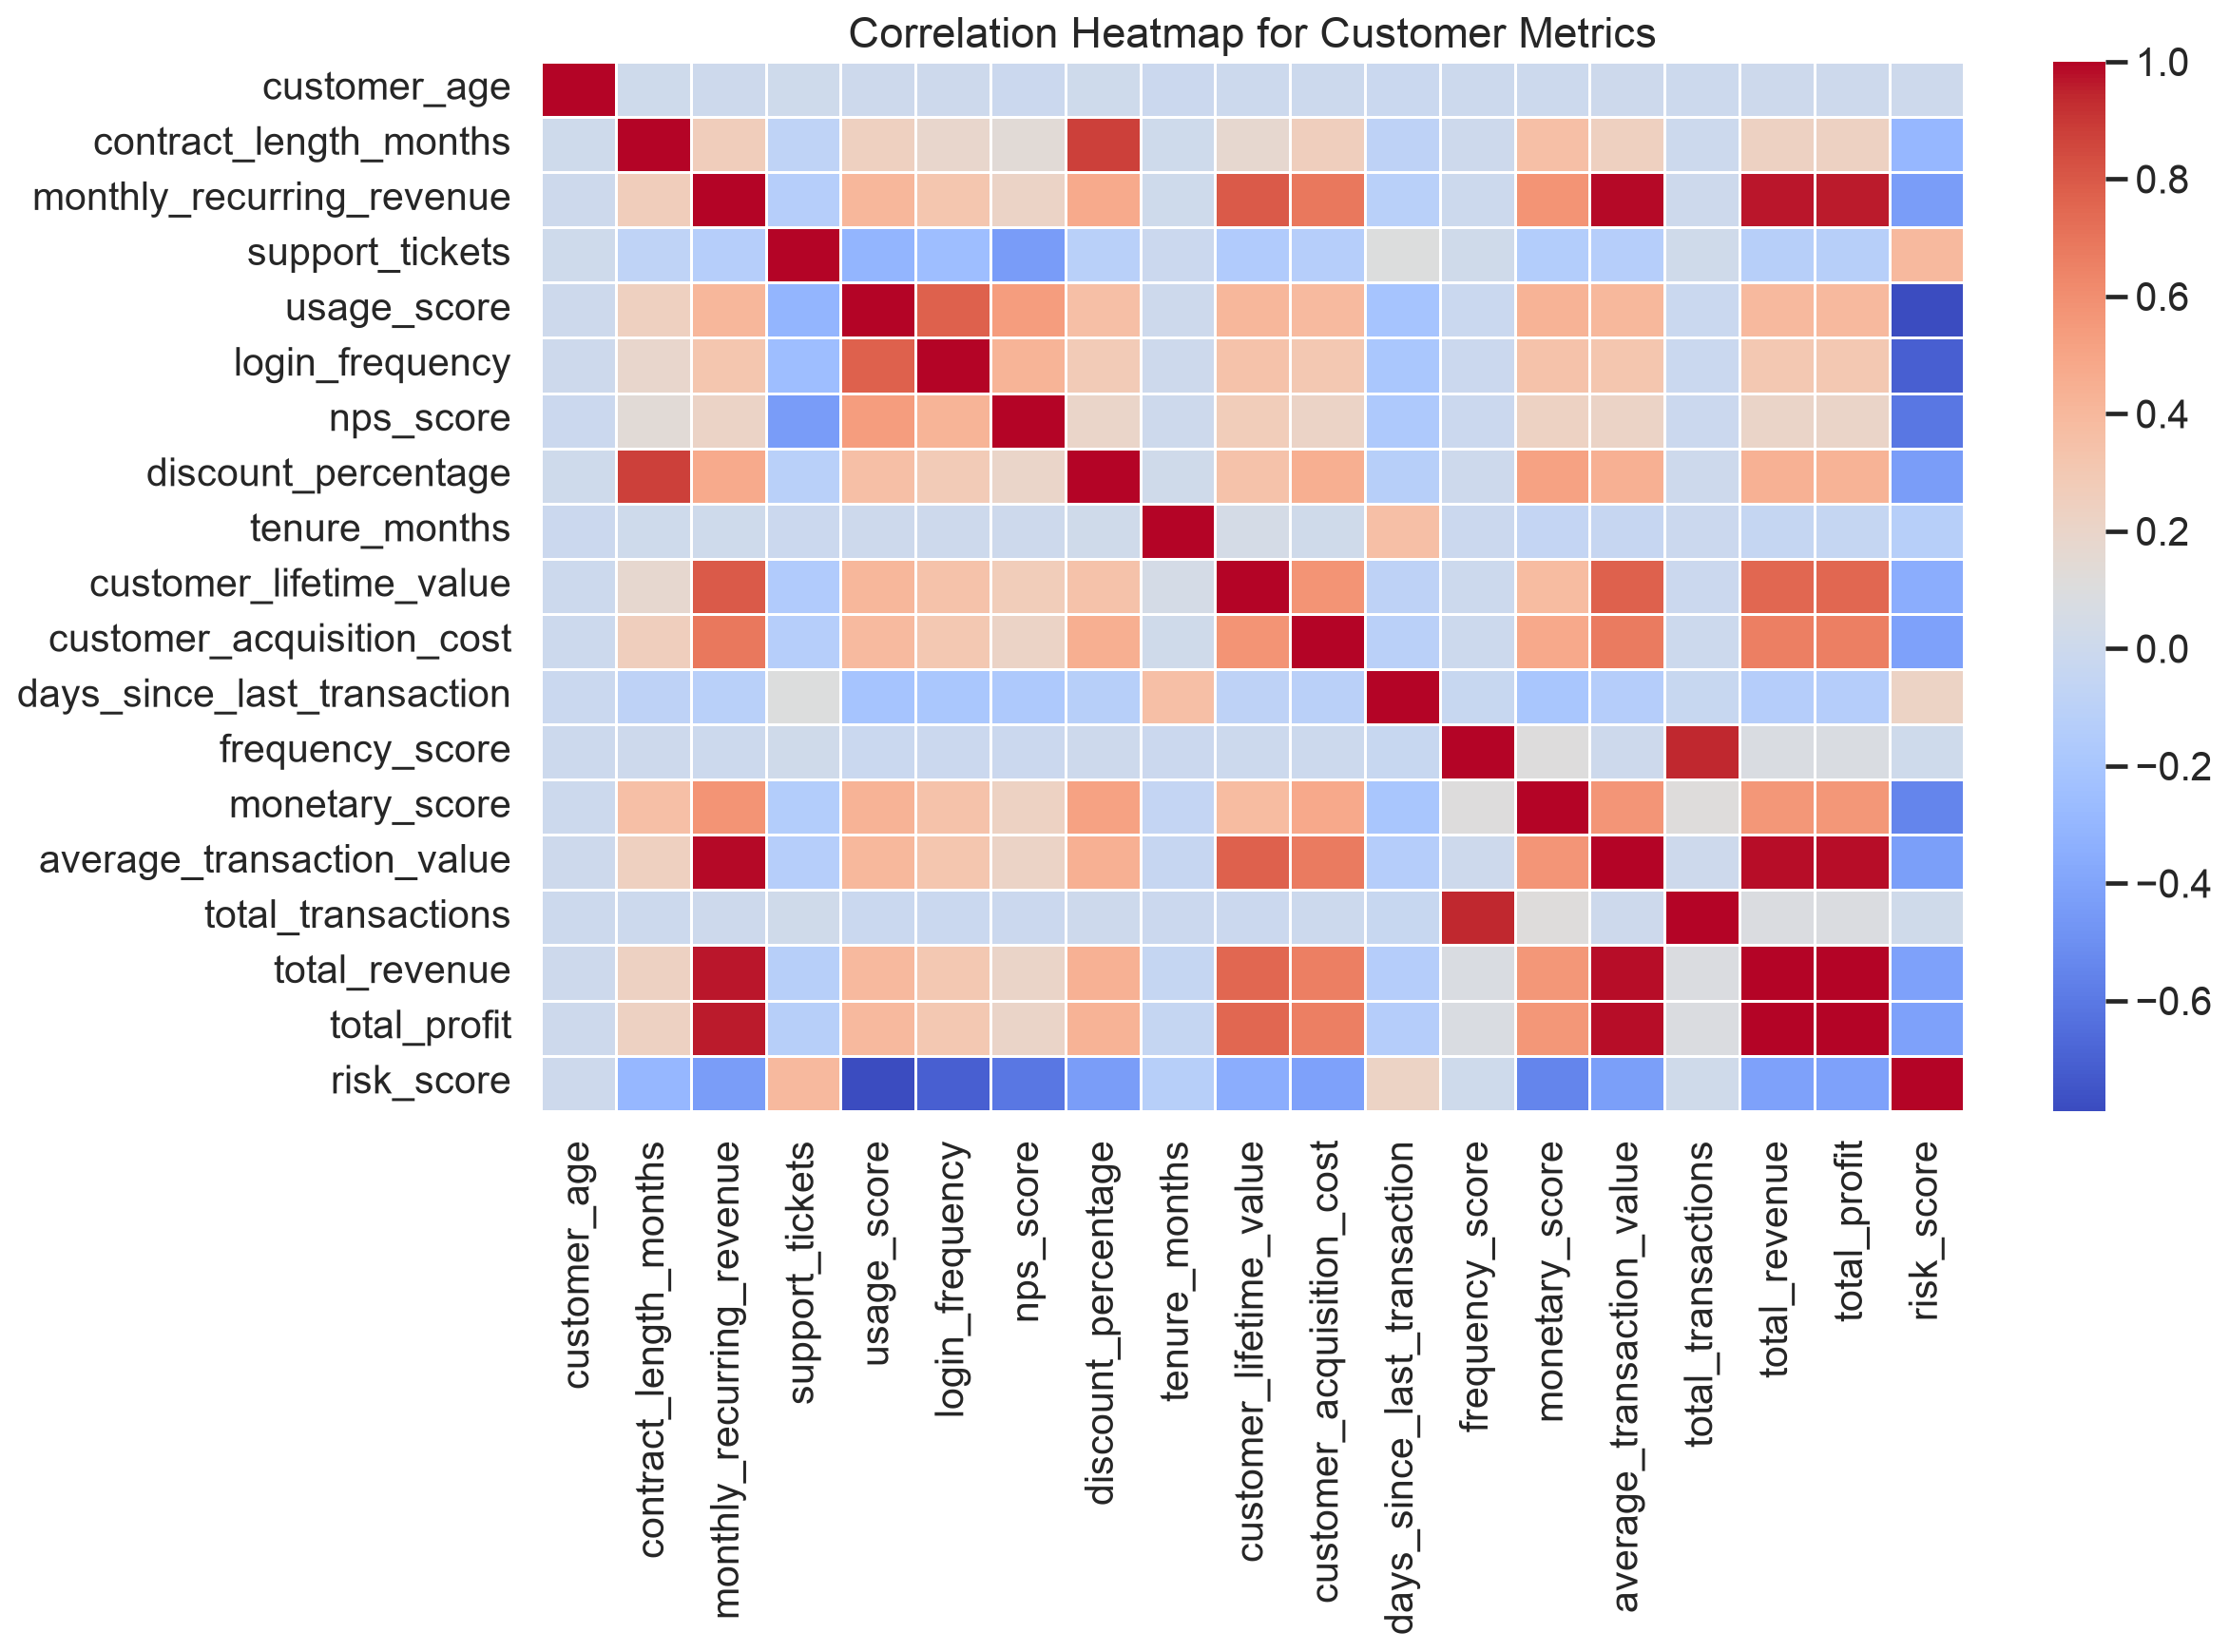

Saved: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/correlation_heatmap.png
Business insight: the strongest relationships indicate which measures tend to move together and which appear more independent in the customer data.


In [13]:
corr_cols = [
    'customer_age', 'contract_length_months', 'monthly_recurring_revenue', 'support_tickets',
    'usage_score', 'login_frequency', 'nps_score', 'discount_percentage', 'tenure_months',
    'customer_lifetime_value', 'customer_acquisition_cost', 'days_since_last_transaction',
    'frequency_score', 'monetary_score', 'average_transaction_value', 'total_transactions',
    'total_revenue', 'total_profit', 'risk_score'
]
corr_frame = customers[[col for col in corr_cols if col in customers.columns]].dropna()
corr_matrix = corr_frame.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5, cbar=True, ax=ax)
ax.set_title('Correlation Heatmap for Customer Metrics')
fig.tight_layout()
output_path = OUTPUT_DIR / 'correlation_heatmap.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {output_path}')
print('Business insight: the strongest relationships indicate which measures tend to move together and which appear more independent in the customer data.')


## Outlier Detection

Outlier detection is conducted using boxplots and interquartile range-based checks on the most relevant numerical variables.


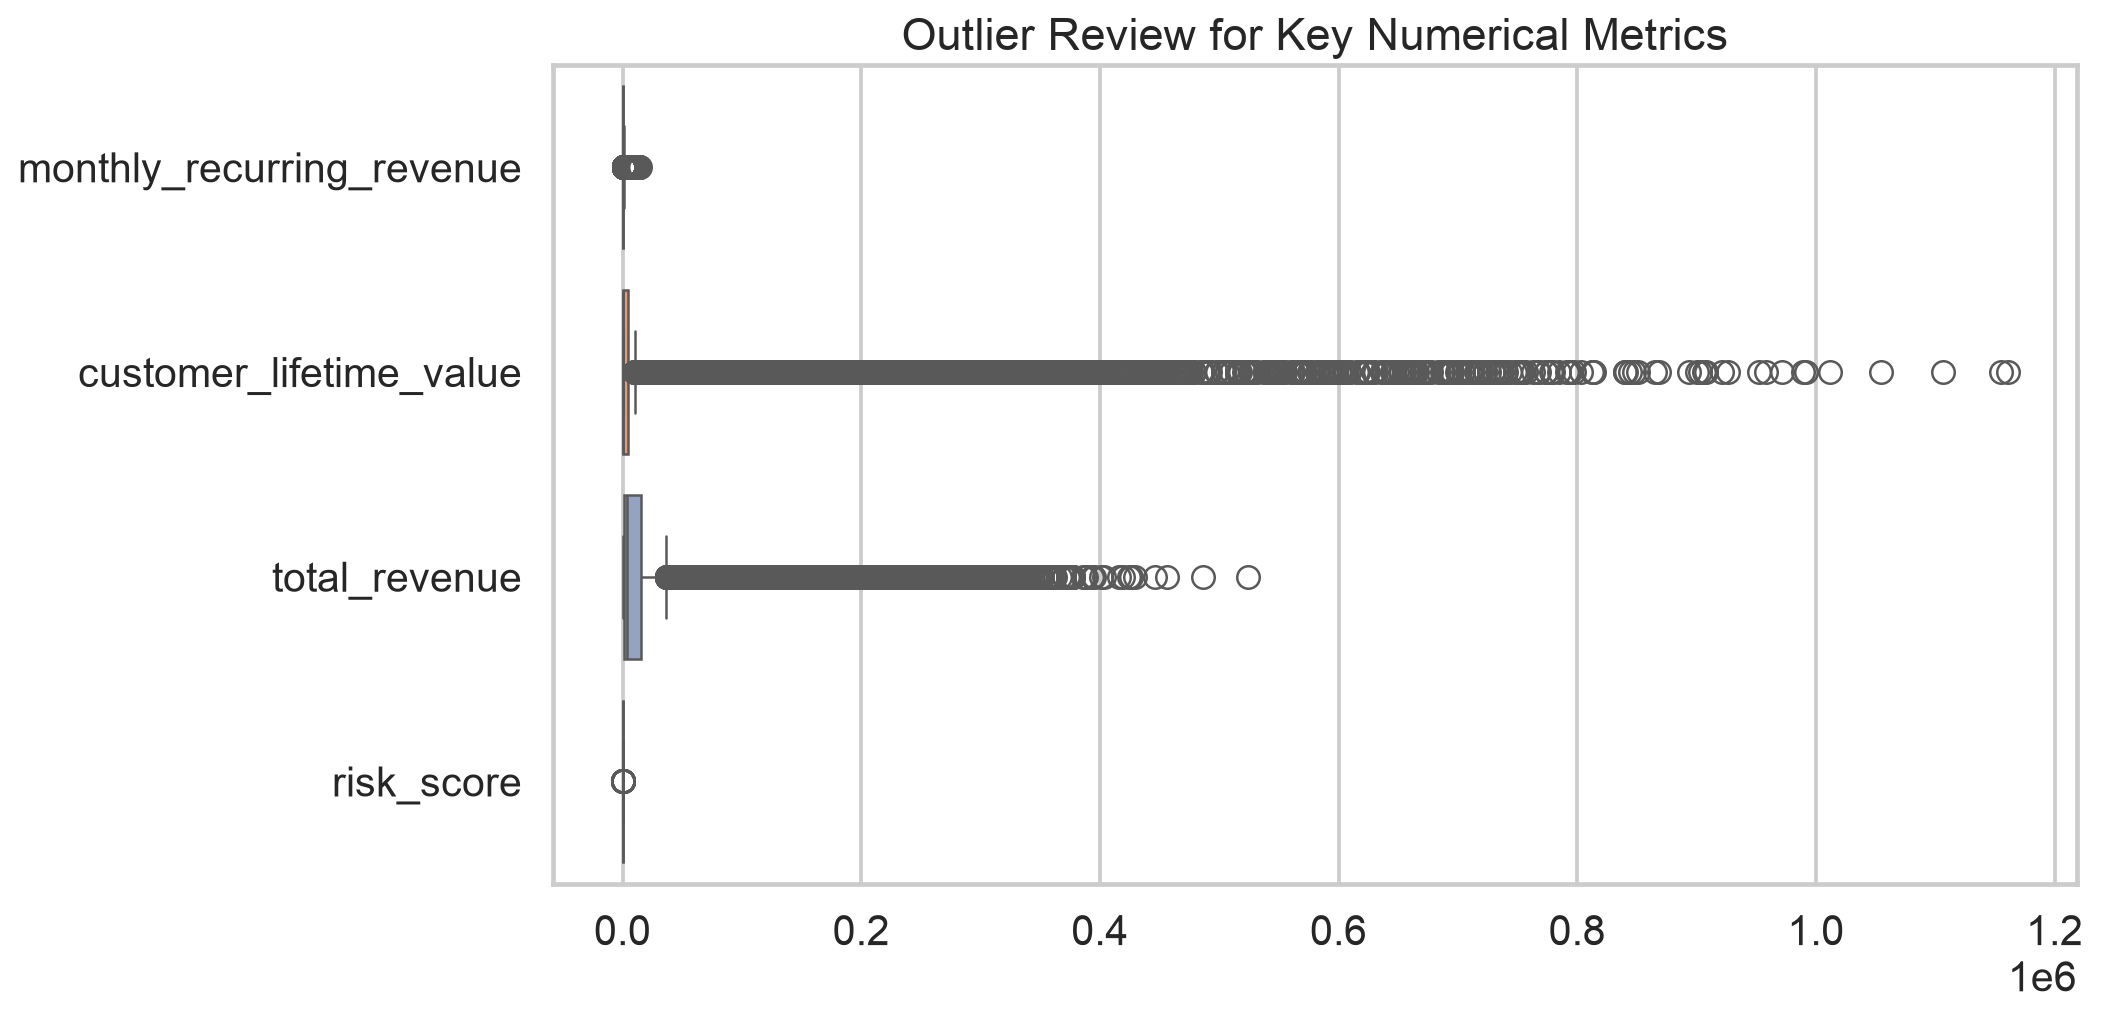

Saved: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/outlier_detection.png
monthly_recurring_revenue: 2832 potential outliers between -776.83 and 1424.31
customer_lifetime_value: 3507 potential outliers between -6163.60 and 10675.47
total_revenue: 2895 potential outliers between -20026.17 and 36856.43
risk_score: 33 potential outliers between -32.45 and 84.75
Business insight: outlier values may represent unusually large accounts or data entry effects and should be reviewed in context rather than removed automatically.


In [14]:
def detect_outliers(series: pd.Series) -> tuple[int, float, float]:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = int(((series < lower_bound) | (series > upper_bound)).sum())
    return outlier_count, lower_bound, upper_bound

outlier_cols = ['monthly_recurring_revenue', 'customer_lifetime_value', 'total_revenue', 'risk_score']
plot_frame = customers[outlier_cols].dropna()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=plot_frame, orient='h', palette='Set2', ax=ax)
ax.set_title('Outlier Review for Key Numerical Metrics')
fig.tight_layout()
output_path = OUTPUT_DIR / 'outlier_detection.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {output_path}')
for col in outlier_cols:
    count, lower, upper = detect_outliers(plot_frame[col])
    print(f'{col}: {count} potential outliers between {lower:.2f} and {upper:.2f}')
print('Business insight: outlier values may represent unusually large accounts or data entry effects and should be reviewed in context rather than removed automatically.')


## Business Insights

The observed patterns are translated into concise business-facing interpretations that rely only on the available data.


In [15]:
print('Business-facing summary:\n')
print(f'- The customer dataset contains {customers.shape[0]:,} records with {customers.shape[1]} attributes.')
print(f'- The transaction dataset contains {transactions.shape[0]:,} records, giving a broad view of operational activity.')
print(f'- Monthly revenue data spans {monthly_revenue.shape[0]} periods, supporting trend and seasonality review.')
print('- The strongest business signals are concentrated around value, engagement, and revenue-related measures rather than purely demographic fields.')
print('- The data indicates that a small number of high-value or high-risk observations can materially influence aggregate patterns and should be reviewed carefully.')


Business-facing summary:

- The customer dataset contains 20,000 records with 36 attributes.
- The transaction dataset contains 329,202 records, giving a broad view of operational activity.
- Monthly revenue data spans 36 periods, supporting trend and seasonality review.
- The strongest business signals are concentrated around value, engagement, and revenue-related measures rather than purely demographic fields.
- The data indicates that a small number of high-value or high-risk observations can materially influence aggregate patterns and should be reviewed carefully.


## EDA Summary

This section consolidates the main findings from the exploratory analysis into a concise narrative.


In [16]:
summary_report = []
summary_report.append('Exploratory Data Analysis Summary')
summary_report.append('---------------------------------')
summary_report.append(f'Customers: {customers.shape[0]:,} rows, {customers.shape[1]} columns')
summary_report.append(f'Transactions: {transactions.shape[0]:,} rows, {transactions.shape[1]} columns')
summary_report.append(f'Monthly Revenue: {monthly_revenue.shape[0]} rows, {monthly_revenue.shape[1]} columns')
summary_report.append('The analysis confirms that the cleaned data is suitable for descriptive and relationship-based review.')
summary_report.append('The most informative patterns are found in revenue, engagement, and customer-value variables.')

print('\n'.join(summary_report))

summary_path = PROJECT_ROOT / 'outputs' / 'eda_summary.txt'
summary_path.write_text('\n'.join(summary_report), encoding='utf-8')
print(f'Saved summary report to {summary_path}')


Exploratory Data Analysis Summary
---------------------------------
Customers: 20,000 rows, 36 columns
Transactions: 329,202 rows, 30 columns
Monthly Revenue: 36 rows, 18 columns
The analysis confirms that the cleaned data is suitable for descriptive and relationship-based review.
The most informative patterns are found in revenue, engagement, and customer-value variables.
Saved summary report to /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/eda_summary.txt


## Key Findings

The final section highlights the primary takeaways from the EDA workflow.


In [17]:
print('Key findings:')
print('1. The cleaned datasets are structurally consistent and ready for exploratory review.')
print('2. Revenue and customer-value metrics show measurable variation across customers and transaction activity.')
print('3. The relationship between engagement and value is visible in the bivariate and multivariate analysis.')
print('4. A small number of high-value or high-risk observations warrant closer inspection in downstream work.')
print('5. The EDA workflow produced reusable visual outputs in the outputs folder for reporting and review.')


Key findings:
1. The cleaned datasets are structurally consistent and ready for exploratory review.
2. Revenue and customer-value metrics show measurable variation across customers and transaction activity.
3. The relationship between engagement and value is visible in the bivariate and multivariate analysis.
4. A small number of high-value or high-risk observations warrant closer inspection in downstream work.
5. The EDA workflow produced reusable visual outputs in the outputs folder for reporting and review.


## Save Visualizations

All generated figures are stored in the outputs folder as high-resolution PNG files for later reporting.


In [18]:
print(f'All visualizations saved in: {OUTPUT_DIR}')
print('Notebook completed successfully.')


All visualizations saved in: /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs
Notebook completed successfully.
